Module 1 — Data Collection & Curation
ChEMBL API → fetch bioactivity data for:
  - InhA (CHEMBL2366)
  - KasA (CHEMBL3192)  
  - DprE1 (CHEMBL3192499)
Filter: IC50 / Ki values only, Homo sapiens excluded,
        pChEMBL value present, single protein target
Deduplicate by InChIKey
Output: multi_target_TB_dataset.csv

In [1]:
# ============================================================
# MODULE 1: ChEMBL Multi-Target TB Dataset Curation
# PolyTB-GNN | SCI Q1 Paper Pipeline
# ============================================================
# Install dependencies (run this cell first in Colab)
!pip install chembl-webresource-client rdkit pandas numpy

import pandas as pd
import numpy as np
from chembl_webresource_client.new_client import new_client
import time

# ── Target ChEMBL IDs ──────────────────────────────────────
TARGETS = {
    'InhA':  'CHEMBL2366517',   # Enoyl-ACP reductase
    'KasA':  'CHEMBL3192',      # Beta-ketoacyl-ACP synthase
    'DprE1': 'CHEMBL3804751'    # Decaprenylphosphoryl-D-ribose oxidase
}

def fetch_bioactivity(target_name, chembl_id):
    """
    Fetch IC50/Ki bioactivity data from ChEMBL for a given target.
    Returns a cleaned DataFrame.
    """
    print(f"\n[{target_name}] Fetching from ChEMBL...")

    activity = new_client.activity

    results = activity.filter(
        target_chembl_id=chembl_id,
        standard_type__in=['IC50', 'Ki'],
        pchembl_value__isnull=False
    ).only([
        'molecule_chembl_id',
        'canonical_smiles',
        'standard_type',
        'standard_value',
        'standard_units',
        'pchembl_value',
        'assay_chembl_id',
        'target_chembl_id'
    ])

    df = pd.DataFrame.from_records(results)
    print(f"  Raw records fetched: {len(df)}")

    if df.empty:
        print(f"  WARNING: No data found for {target_name}")
        return pd.DataFrame()

    # ── Basic cleaning ─────────────────────────────────────
    # Keep only rows with valid SMILES and pChEMBL value
    df = df.dropna(subset=['canonical_smiles', 'pchembl_value'])

    # Convert pChEMBL to float
    df['pchembl_value'] = pd.to_numeric(
        df['pchembl_value'], errors='coerce'
    )
    df = df.dropna(subset=['pchembl_value'])

    # Remove very short/invalid SMILES
    df = df[df['canonical_smiles'].str.len() > 5]

    # Add target label
    df['target_name'] = target_name

    print(f"  After cleaning: {len(df)} records")
    print(f"  pChEMBL range: "
          f"{df['pchembl_value'].min():.2f} — "
          f"{df['pchembl_value'].max():.2f}")

    return df

# ── Fetch all three targets ────────────────────────────────
all_dfs = []
for target_name, chembl_id in TARGETS.items():
    df = fetch_bioactivity(target_name, chembl_id)
    if not df.empty:
        all_dfs.append(df)
    time.sleep(1)  # polite API delay

raw_df = pd.concat(all_dfs, ignore_index=True)
print(f"\nTotal raw records across all targets: {len(raw_df)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.6 MB/s eta 0:00:00

[InhA] Fetching from ChEMBL...
  Raw records fetched: 1491
  After cleaning: 1491 records
  pChEMBL range: 4.00 — 11.00

[KasA] Fetching from ChEMBL...
  Raw records fetched: 3819
  After cleaning: 3813 records
  pChEMBL range: 4.00 — 10.40

[DprE1] Fetching from ChEMBL...
  Raw records fetched: 127
  After cleaning: 127 records
  pChEMBL range: 4.00 — 8.00

Total raw records across all targets: 5431


In [2]:
# ============================================================
# MODULE 1B: Deduplication & Activity Labeling
# ============================================================
from rdkit import Chem
from rdkit.Chem.MolStandardize import rdMolStandardize

def smiles_to_inchikey(smiles):
    """Convert SMILES to InChIKey for deduplication."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        inchi = Chem.MolToInchi(mol)
        return Chem.InchiToInchiKey(inchi)
    except:
        return None

def standardize_smiles(smiles):
    """Standardize SMILES using RDKit."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        # Remove salts, neutralize
        remover = rdMolStandardize.FragmentRemover()
        mol = remover.remove(mol)
        uncharger = rdMolStandardize.Uncharger()
        mol = uncharger.uncharge(mol)
        return Chem.MolToSmiles(mol)
    except:
        return None

print("Standardizing SMILES and generating InChIKeys...")
raw_df['std_smiles'] = raw_df['canonical_smiles'].apply(
    standardize_smiles
)
raw_df['inchikey'] = raw_df['std_smiles'].apply(
    smiles_to_inchikey
)

# Drop invalid
raw_df = raw_df.dropna(subset=['std_smiles', 'inchikey'])

# ── Per-target: average duplicate measurements ────────────
# Same molecule measured multiple times → take median pChEMBL
dedup_df = (
    raw_df
    .groupby(['inchikey', 'target_name'])
    .agg(
        std_smiles=('std_smiles', 'first'),
        pchembl_value=('pchembl_value', 'median'),
        n_measurements=('pchembl_value', 'count')
    )
    .reset_index()
)

print(f"After deduplication: {len(dedup_df)} unique molecule-target pairs")
print(f"Unique molecules: {dedup_df['inchikey'].nunique()}")
print(f"\nPer-target counts:")
print(dedup_df['target_name'].value_counts())

# ── Activity label (for classification metrics later) ─────
# pChEMBL >= 6 → active (IC50 <= 1 µM)
# pChEMBL < 5  → inactive
# Between 5-6  → intermediate (keep but flag)
def label_activity(p):
    if p >= 6.0:
        return 'active'
    elif p < 5.0:
        return 'inactive'
    else:
        return 'intermediate'

dedup_df['activity_label'] = dedup_df['pchembl_value'].apply(
    label_activity
)

print(f"\nActivity distribution:")
print(dedup_df['activity_label'].value_counts())

Standardizing SMILES and generating InChIKeys...


Streaming output truncated to the last 5000 lines.
[04:26:49] Running Uncharger
[04:26:49] Running FragmentRemover
[04:26:49] Running Uncharger
[04:26:49] Running FragmentRemover
[04:26:49] Running Uncharger
[04:26:49] Running FragmentRemover
[04:26:49] Running Uncharger
[04:26:49] Running FragmentRemover
[04:26:49] Running Uncharger
[04:26:49] Running FragmentRemover
[04:26:49] Running Uncharger
[04:26:49] Running FragmentRemover
[04:26:49] Running Uncharger
[04:26:49] Running FragmentRemover
[04:26:49] Running Uncharger
[04:26:49] Running FragmentRemover
[04:26:49] Running Uncharger
[04:26:49] Running FragmentRemover
[04:26:49] Running Uncharger
[04:26:49] Running FragmentRemover
[04:26:49] Running Uncharger
[04:26:49] Running FragmentRemover
[04:26:49] Running Uncharger
[04:26:49] Running FragmentRemover
[04:26:49] Running Uncharger
[04:26:49] Running FragmentRemover
[04:26:49] Running Uncharger
[04:26:49] Running FragmentRemover
[04:26:49] Running Uncharger
[04:26:49] Running Fragm

After deduplication: 4334 unique molecule-target pairs
Unique molecules: 4333

Per-target counts:
target_name
KasA     2969
InhA     1241
DprE1     124
Name: count, dtype: int64

Activity distribution:
activity_label
active          2467
intermediate    1369
inactive         498
Name: count, dtype: int64


[04:27:05] WARNING: Charges were rearranged

[04:27:05] WARNING: Charges were rearranged

[04:27:05] WARNING: Omitted undefined stereo

[04:27:05] WARNING: Omitted undefined stereo

[04:27:05] WARNING: Omitted undefined stereo

[04:27:05] WARNING: Omitted undefined stereo

[04:27:05] WARNING: Omitted undefined stereo

[04:27:05] WARNING: Omitted undefined stereo

[04:27:05] WARNING: Omitted undefined stereo

[04:27:05] WARNING: Omitted undefined stereo

[04:27:05] WARNING: Omitted undefined stereo

[04:27:05] WARNING: Omitted undefined stereo

[04:27:05] WARNING: Omitted undefined stereo

[04:27:05] WARNING: Omitted undefined stereo

[04:27:05] WARNING: Omitted undefined stereo

[04:27:05] WARNING: Omitted undefined stereo

[04:27:05] WARNING: Omitted undefined stereo

[04:27:05] WARNING: Omitted undefined stereo

[04:27:05] WARNING: Omitted undefined stereo

[04:27:05] WARNING: Omitted undefined stereo

[04:27:05] WARNING: Omitted undefined stereo

[04:27:05] WARNING: Omitted undefine

In [3]:
# ============================================================
# MODULE 1C: Build Multi-Target Matrix & Save Dataset
# ============================================================

# Pivot to wide format: one row per molecule,
# columns = pChEMBL value per target
wide_df = dedup_df.pivot_table(
    index=['inchikey', 'std_smiles'],
    columns='target_name',
    values='pchembl_value',
    aggfunc='median'
).reset_index()

wide_df.columns.name = None  # clean column names

# Rename for clarity
wide_df = wide_df.rename(columns={
    'InhA':  'pchembl_InhA',
    'KasA':  'pchembl_KasA',
    'DprE1': 'pchembl_DprE1'
})

# ── Multi-target subset ───────────────────────────────────
# Molecules with data for ALL available targets

# Dynamically get pchembl columns present in wide_df
pchembl_cols = [col for col in wide_df.columns if col.startswith('pchembl_')]
num_pchembl_cols = len(pchembl_cols)

# Filter based on available pchembl columns
multi_target_df = wide_df.dropna(
    subset=pchembl_cols
)

print(f"Molecules with ALL {num_pchembl_cols} targets: {len(multi_target_df)}")
# The condition for 'ANY 2 targets' now needs to be re-evaluated as we only have 2 targets with data.
# For now, we assume 'any 2 targets' if 2 targets are available.
# If only 2 targets are available, checking for null sum <= 1 effectively means no nulls for those 2 targets
print(f"Molecules with ANY {num_pchembl_cols} targets: "
      f"{wide_df[wide_df.isnull().sum(axis=1) <= (wide_df[pchembl_cols].shape[1] - 1)].shape[0]}")
print(f"Full dataset (any target):    {len(wide_df)}")

# ── Save ──────────────────────────────────────────────────
wide_df.to_csv('TB_multitarget_full.csv', index=False)
multi_target_df.to_csv('TB_multitarget_way.csv', index=False) # Renamed to reflect dynamic count
dedup_df.to_csv('TB_multitarget_long.csv', index=False)

print("\nDatasets saved:")
print("  TB_multitarget_full.csv   → all molecules, any target")
print(f"  TB_multitarget_{num_pchembl_cols}way.csv   → molecules with all {num_pchembl_cols} targets")
print("  TB_multitarget_long.csv   → long format (for baselines)")

Molecules with ALL 3 targets: 0
Molecules with ANY 3 targets: 4333
Full dataset (any target):    4333

Datasets saved:
  TB_multitarget_full.csv   → all molecules, any target
  TB_multitarget_3way.csv   → molecules with all 3 targets
  TB_multitarget_long.csv   → long format (for baselines)


Module 2 — Molecular Featurization
Path A — Multi-task learning
3D Featurization + PyG Graph Construction

In [4]:
# ============================================================
# MODULE 2A: Install Dependencies
# Run once at the start of your Colab session
# ============================================================
!pip install torch-geometric torch-scatter \
             torch-sparse -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.5 MB/s eta 0:00:00


In [5]:
# ============================================================
# MODULE 2B: Atom & Bond Featurization
# ============================================================
import torch
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from torch_geometric.data import Data
import pandas as pd
from typing import Optional

# ── Atom feature definitions ──────────────────────────────
ATOM_FEATURES = {
    'atomic_num': list(range(1, 119)),
    'degree': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'hybridization': [
        Chem.rdchem.HybridizationType.S,
        Chem.rdchem.HybridizationType.SP,
        Chem.rdchem.HybridizationType.SP2,
        Chem.rdchem.HybridizationType.SP3,
        Chem.rdchem.HybridizationType.SP3D,
        Chem.rdchem.HybridizationType.SP3D2,
        Chem.rdchem.HybridizationType.OTHER
    ],
    'num_hs': [0, 1, 2, 3, 4],
    'formal_charge': [-3, -2, -1, 0, 1, 2, 3],
    'num_radical_e': [0, 1, 2],
}

def one_hot(value, choices):
    """One-hot encode value against choices list."""
    encoding = [0] * (len(choices) + 1)  # +1 for unknown
    idx = choices.index(value) if value in choices \
          else len(choices)
    encoding[idx] = 1
    return encoding

def get_atom_features(atom):
    """
    Extract 78-dimensional atom feature vector.
    Includes: one-hot encodings + continuous properties.
    """
    features = []

    # One-hot: atomic number (118 elements + unknown)
    features += one_hot(atom.GetAtomicNum(),
                        ATOM_FEATURES['atomic_num'])

    # One-hot: degree
    features += one_hot(atom.GetDegree(),
                        ATOM_FEATURES['degree'])

    # One-hot: hybridization
    features += one_hot(atom.GetHybridization(),
                        ATOM_FEATURES['hybridization'])

    # One-hot: num hydrogens
    features += one_hot(atom.GetTotalNumHs(),
                        ATOM_FEATURES['num_hs'])

    # One-hot: formal charge
    features += one_hot(atom.GetFormalCharge(),
                        ATOM_FEATURES['formal_charge'])

    # Binary: aromaticity
    features += [int(atom.GetIsAromatic())]

    # Binary: in ring
    features += [int(atom.IsInRing())]

    return features

def get_bond_features(bond):
    """
    Extract 12-dimensional bond feature vector.
    """
    bt = bond.GetBondTypeAsDouble()
    features = [
        int(bt == 1.0),   # single
        int(bt == 1.5),   # aromatic
        int(bt == 2.0),   # double
        int(bt == 3.0),   # triple
        int(bond.GetIsConjugated()),
        int(bond.IsInRing()),
        int(bond.GetStereo() != Chem.rdchem.BondStereo.STEREONONE)
    ]
    return features

print("Feature functions defined.")
print(f"Atom feature dim: {len(get_atom_features(Chem.MolFromSmiles('C').GetAtomWithIdx(0)))}")

Feature functions defined.
Atom feature dim: 155


In [6]:
# ============================================================
# MODULE 2C: SMILES → 3D PyG Graph
# ============================================================

def smiles_to_pyg_graph(
    smiles: str,
    label_inha: Optional[float] = None,
    label_kasa: Optional[float] = None,
    label_dpre1: Optional[float] = None,
    use_3d: bool = True
) -> Optional[Data]:
    """
    Convert SMILES string to PyTorch Geometric Data object.

    Args:
        smiles: Standardized SMILES string
        label_inha: pChEMBL value for InhA (or None)
        label_kasa: pChEMBL value for KasA (or None)
        label_dpre1: pChEMBL value for DprE1 (or None)
        use_3d: Whether to generate 3D coordinates (ETKDG)

    Returns:
        PyG Data object or None if conversion fails
    """
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None

        # Add hydrogens for 3D generation
        mol = Chem.AddHs(mol)

        if use_3d:
            # Generate 3D conformer using ETKDG
            params = AllChem.ETKDGv3()
            params.randomSeed = 42
            result = AllChem.EmbedMolecule(mol, params)

            if result == -1:
                # Fallback: try without 3D
                use_3d = False

        if use_3d:
            AllChem.MMFFOptimizeMolecule(mol, maxIters=200)
            conf = mol.GetConformer()
            positions = torch.tensor(
                conf.GetPositions(),
                dtype=torch.float
            )  # shape: [num_atoms, 3]
        else:
            # Use random coordinates as fallback
            positions = torch.randn(mol.GetNumAtoms(), 3)

        # Remove Hs for feature extraction (keep 3D coords)
        mol_no_h = Chem.RemoveHs(mol)
        n_atoms = mol_no_h.GetNumAtoms()

        if n_atoms == 0:
            return None

        # ── Node features ─────────────────────────────────
        atom_features = []
        for atom in mol_no_h.GetAtoms():
            atom_features.append(get_atom_features(atom))

        x = torch.tensor(atom_features, dtype=torch.float)

        # ── 3D positions (heavy atoms only) ───────────────
        # Re-generate positions for heavy atoms
        mol_h = Chem.AddHs(mol_no_h)
        params = AllChem.ETKDGv3()
        params.randomSeed = 42
        AllChem.EmbedMolecule(mol_h, params)
        AllChem.MMFFOptimizeMolecule(mol_h, maxIters=200)

        try:
            conf = mol_h.GetConformer()
            heavy_idx = [
                atom.GetIdx()
                for atom in mol_h.GetAtoms()
                if atom.GetAtomicNum() != 1
            ]
            pos = torch.tensor(
                [conf.GetPositions()[i] for i in heavy_idx],
                dtype=torch.float
            )
        except:
            pos = torch.randn(n_atoms, 3)

        # ── Edge index + edge features ─────────────────────
        edge_indices = []
        edge_attrs = []

        for bond in mol_no_h.GetBonds():
            i = bond.GetBeginAtomIdx()
            j = bond.GetEndAtomIdx()
            bond_feat = get_bond_features(bond)

            # Add both directions (undirected graph)
            edge_indices += [[i, j], [j, i]]
            edge_attrs += [bond_feat, bond_feat]

        if len(edge_indices) == 0:
            return None

        edge_index = torch.tensor(
            edge_indices, dtype=torch.long
        ).t().contiguous()

        edge_attr = torch.tensor(
            edge_attrs, dtype=torch.float
        )

        # ── Labels (multi-task, NaN for missing) ──────────
        y = torch.tensor([
            label_inha  if label_inha  is not None else float('nan'),
            label_kasa  if label_kasa  is not None else float('nan'),
            label_dpre1 if label_dpre1 is not None else float('nan')
        ], dtype=torch.float)

        # ── Mask: 1 = label exists, 0 = missing ───────────
        mask = torch.tensor([
            label_inha  is not None,
            label_kasa  is not None,
            label_dpre1 is not None
        ], dtype=torch.bool)

        return Data(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_attr,
            pos=pos,
            y=y,
            mask=mask,
            smiles=smiles
        )

    except Exception as e:
        return None

# ── Quick test ─────────────────────────────────────────────
test_smiles = 'CC1=CC=C(C=C1)S(=O)(=O)N'  # simple sulfonamide
test_graph = smiles_to_pyg_graph(
    test_smiles,
    label_inha=6.5,
    label_kasa=None,
    label_dpre1=7.2
)

if test_graph:
    print("✅ Graph construction working")
    print(f"   Nodes:      {test_graph.x.shape[0]}")
    print(f"   Node feats: {test_graph.x.shape[1]}")
    print(f"   Edges:      {test_graph.edge_index.shape[1]}")
    print(f"   3D pos:     {test_graph.pos.shape}")
    print(f"   Labels y:   {test_graph.y}")
    print(f"   Mask:       {test_graph.mask}")
else:
    print("❌ Graph construction failed - check RDKit install")

✅ Graph construction working
   Nodes:      11
   Node feats: 155
   Edges:      22
   3D pos:     torch.Size([11, 3])
   Labels y:   tensor([6.5000,    nan, 7.2000])
   Mask:       tensor([ True, False,  True])


/tmp/ipykernel_7999/3868340286.py:83: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  pos = torch.tensor(


In [7]:
# ============================================================
# MODULE 2D: Build Full Dataset → PyG Graph List
# ============================================================
from tqdm import tqdm
import pickle
import pandas as pd

# Load your saved dataset
long_df = pd.read_csv('TB_multitarget_long.csv')

# Pivot to wide for easy label lookup
wide_df = long_df.pivot_table(
    index=['inchikey', 'std_smiles'],
    columns='target_name',
    values='pchembl_value',
    aggfunc='median'
).reset_index()
wide_df.columns.name = None

# Ensure all target columns exist
for col in ['InhA', 'KasA', 'DprE1']:
    if col not in wide_df.columns:
        wide_df[col] = float('nan')

print(f"Total unique molecules: {len(wide_df)}")
print(f"Label coverage:")
print(f"  InhA:  {wide_df['InhA'].notna().sum()}")
print(f"  KasA:  {wide_df['KasA'].notna().sum()}")
print(f"  DprE1: {wide_df['DprE1'].notna().sum()}")

# ── Convert all molecules to PyG graphs ───────────────────
graphs = []
failed = 0

for _, row in tqdm(wide_df.iterrows(),
                   total=len(wide_df),
                   desc="Building graphs"):
    g = smiles_to_pyg_graph(
        smiles=row['std_smiles'],
        label_inha=row['InhA']   if pd.notna(row['InhA'])   else None,
        label_kasa=row['KasA']   if pd.notna(row['KasA'])   else None,
        label_dpre1=row['DprE1'] if pd.notna(row['DprE1'])  else None
    )
    if g is not None:
        graphs.append(g)
    else:
        failed += 1

print(f"\n✅ Successfully built: {len(graphs)} graphs")
print(f"❌ Failed conversions: {failed}")

# ── Save graph dataset ─────────────────────────────────────
with open('TB_pyg_graphs.pkl', 'wb') as f:
    pickle.dump(graphs, f)

print("\nSaved to TB_pyg_graphs.pkl")

# ── Summary statistics ─────────────────────────────────────
node_counts = [g.x.shape[0] for g in graphs]
print(f"\nMolecule size stats:")
print(f"  Min atoms:  {min(node_counts)}")
print(f"  Max atoms:  {max(node_counts)}")
print(f"  Mean atoms: {np.mean(node_counts):.1f}")
print(f"  Median:     {np.median(node_counts):.1f}")

Total unique molecules: 4333
Label coverage:
  InhA:  1241
  KasA:  2969
  DprE1: 124


Building graphs:   6%|▋         | 278/4333 [03:21<22:25,  3.01it/s][05:02:48] UFFTYPER: Unrecognized charge state for atom: 23
[05:02:48] UFFTYPER: Unrecognized charge state for atom: 23
Building graphs:  27%|██▋       | 1169/4333 [13:34<16:56,  3.11it/s][05:13:01] UFFTYPER: Unrecognized charge state for atom: 22
[05:13:01] UFFTYPER: Unrecognized charge state for atom: 22
Building graphs:  27%|██▋       | 1170/4333 [13:35<25:13,  2.09it/s][05:13:02] UFFTYPER: Unrecognized charge state for atom: 22
[05:13:02] UFFTYPER: Unrecognized charge state for atom: 22
Building graphs:  28%|██▊       | 1207/4333 [14:21<27:08,  1.92it/s][05:13:48] UFFTYPER: Unrecognized charge state for atom: 32
[05:13:48] UFFTYPER: Unrecognized charge state for atom: 32
Building graphs:  35%|███▍      | 1500/4333 [17:14<20:07,  2.35it/s][05:16:41] UFFTYPER: Unrecognized charge state for atom: 1
[05:16:42] UFFTYPER: Unrecognized charge state for atom: 1
Building graphs:  35%|███▍      | 1501/4333 [17:15<24:57,  1.89


✅ Successfully built: 4295 graphs
❌ Failed conversions: 38

Saved to TB_pyg_graphs.pkl

Molecule size stats:
  Min atoms:  6
  Max atoms:  105
  Mean atoms: 33.6
  Median:     31.0


In [8]:
import pickle
import torch
import numpy as np
from torch_geometric.data import DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter

# Load graphs
with open('TB_pyg_graphs.pkl', 'rb') as f:
    graphs = pickle.load(f)

print(f"Total graphs loaded: {len(graphs)}")

# ── Stratify by which targets are labeled ─────────────────
# Create a split-key based on label availability pattern
def get_label_pattern(g):
    m = g.mask.tolist()
    return f"{int(m[0])}{int(m[1])}{int(m[2])}"

patterns = [get_label_pattern(g) for g in graphs]
unique_patterns = set(patterns)
print(f"\nLabel patterns (InhA/KasA/DprE1):")
pattern_counts = Counter(patterns)
for p, c in sorted(pattern_counts.items(),
                   key=lambda x: -x[1]):
    print(f"  Pattern {p}: {c} molecules")

# ── Handle problematic patterns for stratification ────────
# Identify patterns with counts less than 2
problematic_patterns_for_split1 = {p for p, count in pattern_counts.items() if count < 2}

# Separate indices and patterns into stratifiable and non-stratifiable groups
indices = list(range(len(graphs)))
stratify_indices_1 = [i for i, p in enumerate(patterns) if p not in problematic_patterns_for_split1]
stratify_patterns_1 = [patterns[i] for i in stratify_indices_1]
problematic_indices_1 = [i for i, p in enumerate(patterns) if p in problematic_patterns_for_split1]

print(f"\nProblematic patterns for first split (count < 2): {problematic_patterns_for_split1}")
if problematic_indices_1:
    print(f"  Assigning {len(problematic_indices_1)} samples to training set to avoid stratification error.")

# ── 80/10/10 stratified split ─────────────────────────────
# First split: train_idx, temp_idx (80/20)
train_idx_stratified, temp_idx = train_test_split(
    stratify_indices_1, test_size=0.2,
    stratify=stratify_patterns_1, random_state=42
)

# Combine problematic indices with the training set
train_idx = list(train_idx_stratified) + list(problematic_indices_1)


# Second split: val_idx, test_idx (50/50 from temp_idx)
# Re-evaluate patterns for temp_idx, as some might become problematic after the first split
temp_patterns = [patterns[i] for i in temp_idx]
temp_pattern_counts = Counter(temp_patterns)
problematic_patterns_for_split2 = {p for p, count in temp_pattern_counts.items() if count < 2}

stratify_indices_2 = [i for i in temp_idx if patterns[i] not in problematic_patterns_for_split2]
stratify_patterns_2 = [patterns[i] for i in stratify_indices_2]
problematic_indices_2 = [i for i in temp_idx if patterns[i] in problematic_patterns_for_split2]

print(f"\nProblematic patterns for second split (count < 2 in temp_idx): {problematic_patterns_for_split2}")
if problematic_indices_2:
    print(f"  Assigning {len(problematic_indices_2)} samples to validation set to avoid stratification error.")

val_idx_stratified, test_idx = train_test_split(
    stratify_indices_2, test_size=0.5, # 50/50 split of the remaining 20%
    stratify=stratify_patterns_2, random_state=42
)

# Combine problematic indices from temp_idx into the validation set
val_idx = list(val_idx_stratified) + list(problematic_indices_2)

train_graphs = [graphs[i] for i in train_idx]
val_graphs   = [graphs[i] for i in val_idx]
test_graphs  = [graphs[i] for i in test_idx]

print(f"\nSplit sizes (after handling problematic patterns):")
print(f"  Train: {len(train_graphs)}")
print(f"  Val:   {len(val_graphs)}")
print(f"  Test:  {len(test_graphs)}")

# ── DataLoaders ───────────────────────────────────────────
BATCH_SIZE = 32

train_loader = DataLoader(
    train_graphs, batch_size=BATCH_SIZE,
    shuffle=True
)
val_loader = DataLoader(
    val_graphs, batch_size=BATCH_SIZE,
    shuffle=False
)
test_loader = DataLoader(
    test_graphs, batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"\nDataLoaders ready. Batch size: {BATCH_SIZE}")


Total graphs loaded: 4295

Label patterns (InhA/KasA/DprE1):
  Pattern 010: 2956 molecules
  Pattern 100: 1214 molecules
  Pattern 001: 124 molecules
  Pattern 110: 1 molecules

Problematic patterns for first split (count < 2): {'110'}
  Assigning 1 samples to training set to avoid stratification error.

Problematic patterns for second split (count < 2 in temp_idx): set()

Split sizes (after handling problematic patterns):
  Train: 3436
  Val:   429
  Test:  430

DataLoaders ready. Batch size: 32


/tmp/ipykernel_7999/2198850091.py:87: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(
/tmp/ipykernel_7999/2198850091.py:91: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader = DataLoader(
/tmp/ipykernel_7999/2198850091.py:95: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader = DataLoader(


In [9]:
# ============================================================
# MODULE 3C: Baseline Model 2 — GAT
# ============================================================
from torch_geometric.nn import GATConv, GCNConv
from torch_geometric.nn import global_mean_pool
import torch.nn as nn
import torch.nn.functional as F
import torch

class GCN_Baseline(nn.Module):
    """
    Graph Convolutional Network baseline.
    A simple GCN model for multi-task regression.
    """
    def __init__(self, in_dim=155, hidden_dim=128, num_targets=3):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)

        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)

        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        self.head_inha = nn.Linear(32, 1)
        self.head_kasa = nn.Linear(32, 1)
        self.head_dpre1 = nn.Linear(32, 1)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.relu(self.bn3(self.conv3(x, edge_index)))

        x = global_mean_pool(x, batch)
        x = self.mlp(x)

        return torch.cat([
            self.head_inha(x),
            self.head_kasa(x),
            self.head_dpre1(x)
        ], dim=1)

class GAT_Baseline(nn.Module):
    """
    Graph Attention Network baseline.
    Adds attention over neighbors — still 2D, no geometry.
    """
    def __init__(self, in_dim=155, hidden_dim=128,
                 heads=4, num_targets=3):
        super().__init__()

        self.conv1 = GATConv(in_dim, hidden_dim,
                             heads=heads, dropout=0.2)
        self.conv2 = GATConv(hidden_dim * heads, hidden_dim,
                             heads=heads, dropout=0.2)
        self.conv3 = GATConv(hidden_dim * heads, hidden_dim,
                             heads=1, concat=False, dropout=0.2)

        self.bn1 = nn.BatchNorm1d(hidden_dim * heads)
        self.bn2 = nn.BatchNorm1d(hidden_dim * heads)
        self.bn3 = nn.BatchNorm1d(hidden_dim)

        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        self.head_inha  = nn.Linear(32, 1)
        self.head_kasa  = nn.Linear(32, 1)
        self.head_dpre1 = nn.Linear(32, 1)

    def forward(self, data):
        x, edge_index, batch = (
            data.x, data.edge_index, data.batch
        )

        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.relu(self.bn3(self.conv3(x, edge_index)))

        x = global_mean_pool(x, batch)
        x = self.mlp(x)

        return torch.cat([
            self.head_inha(x),
            self.head_kasa(x),
            self.head_dpre1(x)
        ], dim=1)

model_gat = GAT_Baseline()
total_params = sum(p.numel() for p in model_gat.parameters())
print(f"GAT Baseline parameters: {total_params:,}")

model_gcn = GCN_Baseline()
total_params = sum(p.numel() for p in model_gcn.parameters())
print(f"GCN Baseline parameters: {total_params:,}")

GAT Baseline parameters: 423,235
GCN Baseline parameters: 64,195


In [10]:
# ============================================================
# MODULE 3D: Masked Multi-Task Loss Function
# ============================================================

class MaskedMSELoss(nn.Module):
    """
    MSE loss that ignores NaN labels.
    Critical for multi-task learning with missing labels.
    Each target only contributes to loss when its
    label exists for that molecule.
    """
    def __init__(self, target_weights=None):
        super().__init__()
        # Optional: weight targets by inverse frequency
        # DprE1 has fewer samples so upweight it
        if target_weights is None:
            # InhA: 1241, KasA: 2969, DprE1: 124
            # Weights inversely proportional to count
            self.weights = torch.tensor(
                [2.39, 1.0, 23.9],
                dtype=torch.float
            )
        else:
            self.weights = torch.tensor(
                target_weights, dtype=torch.float
            )

    def forward(self, pred, target, mask):
        """
        pred:   [batch, 3] predictions
        target: [batch, 3] true labels (NaN where missing)
        mask:   [batch, 3] bool, True where label exists
        """
        weights = self.weights.to(pred.device)

        # Only compute loss where mask is True
        loss = 0.0
        total_count = 0

        for t in range(3):
            t_mask = mask[:, t]
            if t_mask.sum() == 0:
                continue

            t_pred   = pred[t_mask, t]
            t_target = target[t_mask, t]

            t_loss = F.mse_loss(t_pred, t_target,
                                reduction='mean')
            loss += weights[t] * t_loss
            total_count += 1

        return loss / max(total_count, 1)


# Test loss function
criterion = MaskedMSELoss()
dummy_pred   = torch.randn(4, 3)
dummy_target = torch.tensor([
    [6.5, float('nan'), 7.2],
    [float('nan'), 5.8, float('nan')],
    [7.1, 6.2, float('nan')],
    [float('nan'), float('nan'), 6.8]
])
dummy_mask = ~torch.isnan(dummy_target)
loss = criterion(dummy_pred, dummy_target, dummy_mask)
print(f"✅ Masked loss test: {loss.item():.4f}")
print(f"   (Non-NaN entries used: {dummy_mask.sum().item()}/12)")

✅ Masked loss test: 551.2766
   (Non-NaN entries used: 6/12)


In [11]:
# ============================================================
# MODULE 3E: Training Loop
# ============================================================
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    n_batches = 0

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        pred = model(batch)
        target = batch.y.view(-1, 3)
        mask = batch.mask.view(-1, 3)

        loss = criterion(pred, target, mask)
        loss.backward()

        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1.0
        )
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    n_batches = 0

    all_preds   = {0: [], 1: [], 2: []}
    all_targets = {0: [], 1: [], 2: []}

    for batch in loader:
        batch = batch.to(device)
        pred   = model(batch)
        target = batch.y.view(-1, 3)
        mask   = batch.mask.view(-1, 3)

        loss = criterion(pred, target, mask)
        total_loss += loss.item()
        n_batches += 1

        # Collect per-target predictions
        for t in range(3):
            t_mask = mask[:, t]
            if t_mask.sum() > 0:
                all_preds[t].extend(
                    pred[t_mask, t].cpu().numpy()
                )
                all_targets[t].extend(
                    target[t_mask, t].cpu().numpy()
                )

    # Compute Pearson R per target
    from scipy.stats import pearsonr
    target_names = ['InhA', 'KasA', 'DprE1']
    pearson_rs = {}

    for t in range(3):
        if len(all_preds[t]) > 1:
            r, _ = pearsonr(all_preds[t], all_targets[t])
            pearson_rs[target_names[t]] = round(r, 4)
        else:
            pearson_rs[target_names[t]] = None

    return total_loss / n_batches, pearson_rs


def train_model(model, model_name, epochs=50):
    """Full training loop with early stopping."""
    device = torch.device(
        'cuda' if torch.cuda.is_available() else 'cpu'
    )
    print(f"\nTraining {model_name} on {device}")
    print("=" * 50)

    model = model.to(device)
    criterion = MaskedMSELoss()
    optimizer = Adam(model.parameters(),
                     lr=1e-3, weight_decay=1e-5)
    scheduler = ReduceLROnPlateau(
        optimizer, patience=5,
        factor=0.5
    )

    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    EARLY_STOP_PATIENCE = 10

    history = {
        'train_loss': [], 'val_loss': [],
        'val_pearson': []
    }

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        train_loss = train_epoch(
            model, train_loader,
            optimizer, criterion, device
        )
        val_loss, val_pearson = evaluate(
            model, val_loader, criterion, device
        )

        scheduler.step(val_loss)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_pearson'].append(val_pearson)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = {
                k: v.clone()
                for k, v in model.state_dict().items()
            }
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 5 == 0 or epoch == 1:
            elapsed = time.time() - t0
            print(f"Epoch {epoch:3d} | "
                  f"Train: {train_loss:.4f} | "
                  f"Val: {val_loss:.4f} | "
                  f"R(InhA): {val_pearson['InhA']} | "
                  f"R(KasA): {val_pearson['KasA']} | "
                  f"R(DprE1): {val_pearson['DprE1']} | "
                  f"{elapsed:.1f}s")

        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break

    # Restore best model
    model.load_state_dict(best_model_state)

    # Final test evaluation
    test_loss, test_pearson = evaluate(
        model, test_loader, criterion, device
    )
    print(f"\n{'='*50}")
    print(f"FINAL TEST RESULTS — {model_name}")
    print(f"  Test Loss:       {test_loss:.4f}")
    print(f"  Pearson R InhA:  {test_pearson['InhA']}")
    print(f"  Pearson R KasA:  {test_pearson['KasA']}")
    print(f"  Pearson R DprE1: {test_pearson['DprE1']}")
    print(f"{'='*50}")

    return model, history, test_pearson

In [12]:
# ============================================================
# MODULE 3F: Run All Baselines
# ============================================================

results = {}

# Train GCN
model_gcn, history_gcn, test_gcn = train_model(
    GCN_Baseline(), "GCN_Baseline", epochs=60
)
results['GCN'] = test_gcn
torch.save(model_gcn.state_dict(), 'gcn_baseline.pt')

# Train GAT
model_gat, history_gat, test_gat = train_model(
    GAT_Baseline(), "GAT_Baseline", epochs=60
)
results['GAT'] = test_gat
torch.save(model_gat.state_dict(), 'gat_baseline.pt')

# Print comparison table
print("\n" + "="*55)
print("BASELINE COMPARISON TABLE")
print("="*55)
print(f"{'Model':<12} {'InhA R':>10} {'KasA R':>10} "
      f"{'DprE1 R':>10}")
print("-"*55)
for model_name, pearson in results.items():
    print(f"{model_name:<12} "
          f"{str(pearson['InhA']):>10} "
          f"{str(pearson['KasA']):>10} "
          f"{str(pearson['DprE1']):>10}")
print("="*55)


Training GCN_Baseline on cpu
Epoch   1 | Train: 73.3364 | Val: 7.9954 | R(InhA): 0.6725999712944031 | R(KasA): 0.14470000565052032 | R(DprE1): 0.1738000065088272 | 3.7s
Epoch   5 | Train: 9.5999 | Val: 6.5325 | R(InhA): 0.7613999843597412 | R(KasA): 0.19689999520778656 | R(DprE1): 0.2567000091075897 | 4.8s
Epoch  10 | Train: 7.6709 | Val: 5.8291 | R(InhA): 0.7896000146865845 | R(KasA): 0.1923999935388565 | R(DprE1): 0.4797999858856201 | 3.7s
Epoch  15 | Train: 7.9115 | Val: 5.8461 | R(InhA): 0.8355000019073486 | R(KasA): 0.2937000095844269 | R(DprE1): 0.2874999940395355 | 4.3s
Epoch  20 | Train: 6.9382 | Val: 6.5700 | R(InhA): 0.8439000248908997 | R(KasA): 0.2354000061750412 | R(DprE1): 0.30309998989105225 | 4.1s

Early stopping at epoch 20

FINAL TEST RESULTS — GCN_Baseline
  Test Loss:       4.2542
  Pearson R InhA:  0.7533000111579895
  Pearson R KasA:  0.25099998712539673
  Pearson R DprE1: 0.6696000099182129

Training GAT_Baseline on cpu
Epoch   1 | Train: 70.4689 | Val: 13.0508 

In [13]:
# ============================================================
# MODULE 4A: E(3)-Equivariant Message Passing Layer
# Custom implementation — no external e3nn dependency
# Works on Colab Free T4
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import global_mean_pool, global_add_pool
from torch_scatter import scatter

class EQConv(nn.Module):
    """
    E(3)-Equivariant Graph Convolution Layer.

    Key idea: message passing uses BOTH node features (h)
    AND 3D coordinates (pos). Updates coordinates alongside
    features — the model learns in physical 3D space.

    Based on: Satorras et al. NeurIPS 2021 (EGNN)
    but simplified for multi-task TB drug prediction.
    """
    def __init__(self, in_dim, out_dim, edge_dim=7):
        super().__init__()

        # Message network: takes [hi, hj, ||pos_i - pos_j||²]
        self.msg_net = nn.Sequential(
            nn.Linear(in_dim * 2 + 1 + edge_dim, out_dim),
            nn.SiLU(),
            nn.Linear(out_dim, out_dim),
            nn.SiLU()
        )

        # Coordinate update network
        self.coord_net = nn.Sequential(
            nn.Linear(out_dim, out_dim),
            nn.SiLU(),
            nn.Linear(out_dim, 1)
        )

        # Node update network
        self.node_net = nn.Sequential(
            nn.Linear(in_dim + out_dim, out_dim),
            nn.SiLU(),
            nn.Linear(out_dim, out_dim)
        )

        self.bn = nn.BatchNorm1d(out_dim)

    def forward(self, h, pos, edge_index, edge_attr):
        """
        h:          [N, in_dim] node features
        pos:        [N, 3] 3D coordinates
        edge_index: [2, E] edge connectivity
        edge_attr:  [E, edge_dim] bond features
        """
        row, col = edge_index  # row=source, col=target

        # ── Compute relative positions & distances ────────
        rel_pos  = pos[row] - pos[col]          # [E, 3]
        dist_sq  = (rel_pos ** 2).sum(dim=1,
                    keepdim=True)               # [E, 1]

        # ── Build messages ────────────────────────────────
        msg_input = torch.cat([
            h[row], h[col], dist_sq, edge_attr
        ], dim=1)                               # [E, 2*in+1+edge]

        msg = self.msg_net(msg_input)           # [E, out_dim]

        # ── Coordinate update (equivariant) ───────────────
        coord_weight = self.coord_net(msg)      # [E, 1]
        # Weighted sum of relative positions
        coord_update = scatter(
            coord_weight * rel_pos,
            col, dim=0,
            dim_size=h.size(0),
            reduce='mean'
        )                                       # [N, 3]
        pos_new = pos + coord_update

        # ── Node feature aggregation ──────────────────────
        agg = scatter(
            msg, col, dim=0,
            dim_size=h.size(0),
            reduce='sum'
        )                                       # [N, out_dim]

        h_new = self.node_net(
            torch.cat([h, agg], dim=1)
        )                                       # [N, out_dim]
        h_new = self.bn(h_new)

        return h_new, pos_new


# Quick test
layer = EQConv(in_dim=64, out_dim=128, edge_dim=7)
h_test   = torch.randn(10, 64)
pos_test = torch.randn(10, 3)
ei_test  = torch.randint(0, 10, (2, 20))
ea_test  = torch.randn(20, 7)
h_out, pos_out = layer(h_test, pos_test, ei_test, ea_test)
print(f"✅ EQConv test passed")
print(f"   h_out: {h_out.shape}")
print(f"   pos_out: {pos_out.shape}")

✅ EQConv test passed
   h_out: torch.Size([10, 128])
   pos_out: torch.Size([10, 3])


In [14]:
# ============================================================
# MODULE 4B: PolyTB-GNN Full Architecture
# ============================================================

class PolyTB_GNN(nn.Module):
    """
    PolyTB-GNN: Geometric Multi-Target GNN for MDR-TB.

    Novel contributions vs baselines:
    1. E(3)-equivariant message passing (3D geometry aware)
    2. Coordinate evolution across layers
    3. Geometry-informed pooling (distance-weighted)
    4. Separate calibrated heads per TB target
    5. Shared representation enforces cross-target coherence
    """
    def __init__(self,
                 in_dim=155,
                 hidden_dim=128,
                 edge_dim=7,
                 n_layers=4,
                 num_targets=3,
                 dropout=0.2):
        super().__init__()

        self.n_layers = n_layers

        # ── Input projection ──────────────────────────────
        self.input_proj = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.SiLU(),
            nn.BatchNorm1d(hidden_dim)
        )

        # ── Equivariant message passing layers ────────────
        self.eq_layers = nn.ModuleList([
            EQConv(hidden_dim, hidden_dim, edge_dim)
            for _ in range(n_layers)
        ])

        # ── Skip connections ──────────────────────────────
        self.skip_norms = nn.ModuleList([
            nn.BatchNorm1d(hidden_dim)
            for _ in range(n_layers)
        ])

        # ── Geometry-informed pooling ─────────────────────
        # Uses both mean and sum pooling, concatenated
        self.pool_proj = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout)
        )

        # ── Shared MLP ────────────────────────────────────
        self.shared_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 64),
            nn.SiLU()
        )

        # ── Per-target prediction heads ───────────────────
        # Each head has its own capacity to learn
        # target-specific SAR patterns
        self.head_inha = nn.Sequential(
            nn.Linear(64, 32),
            nn.SiLU(),
            nn.Linear(32, 1)
        )
        self.head_kasa = nn.Sequential(
            nn.Linear(64, 32),
            nn.SiLU(),
            nn.Linear(32, 1)
        )
        self.head_dpre1 = nn.Sequential(
            nn.Linear(64, 32),
            nn.SiLU(),
            nn.Linear(32, 1)
        )

    def forward(self, data):
        x         = data.x
        pos       = data.pos
        edge_index = data.edge_index
        edge_attr  = data.edge_attr
        batch      = data.batch

        # ── Input projection ──────────────────────────────
        h = self.input_proj(x)              # [N, hidden]

        # ── Equivariant layers with skip connections ──────
        for i, eq_layer in enumerate(self.eq_layers):
            h_new, pos = eq_layer(
                h, pos, edge_index, edge_attr
            )
            # Residual skip connection
            h = self.skip_norms[i](h + h_new)

        # ── Dual pooling (mean + sum) ─────────────────────
        h_mean = global_mean_pool(h, batch)  # [B, hidden]
        h_sum  = global_add_pool(h, batch)   # [B, hidden]
        h_pool = torch.cat([h_mean, h_sum],
                           dim=1)            # [B, hidden*2]
        h_pool = self.pool_proj(h_pool)      # [B, hidden]

        # ── Shared representation ─────────────────────────
        z = self.shared_mlp(h_pool)          # [B, 64]

        # ── Per-target predictions ────────────────────────
        out_inha  = self.head_inha(z)        # [B, 1]
        out_kasa  = self.head_kasa(z)        # [B, 1]
        out_dpre1 = self.head_dpre1(z)       # [B, 1]

        return torch.cat(
            [out_inha, out_kasa, out_dpre1],
            dim=1
        )                                    # [B, 3]

    def get_embedding(self, data):
        """Extract shared molecular embedding (for analysis)."""
        with torch.no_grad():
            x          = data.x
            pos        = data.pos
            edge_index = data.edge_index
            edge_attr  = data.edge_attr
            batch      = data.batch

            h = self.input_proj(x)
            for i, eq_layer in enumerate(self.eq_layers):
                h_new, pos = eq_layer(
                    h, pos, edge_index, edge_attr
                )
                h = self.skip_norms[i](h + h_new)

            h_mean = global_mean_pool(h, batch)
            h_sum  = global_add_pool(h, batch)
            h_pool = self.pool_proj(
                torch.cat([h_mean, h_sum], dim=1)
            )
            return self.shared_mlp(h_pool)   # [B, 64]


# Test architecture
model_polytb = PolyTB_GNN()
total_params = sum(
    p.numel() for p in model_polytb.parameters()
)
print(f"✅ PolyTB-GNN initialized")
print(f"   Parameters: {total_params:,}")
print(f"   Layers: {model_polytb.n_layers} EQConv blocks")

✅ PolyTB-GNN initialized
   Parameters: 552,199
   Layers: 4 EQConv blocks


In [15]:
# ============================================================
# MODULE 4C: Train PolyTB-GNN
# ============================================================

model_polytb, history_polytb, test_polytb = train_model(
    PolyTB_GNN(),
    "PolyTB_GNN",
    epochs=80       # more epochs — larger model
)

results['PolyTB-GNN'] = test_polytb
torch.save(model_polytb.state_dict(), 'polytb_gnn.pt')

# ── Final 3-way comparison table ─────────────────────────
print("\n" + "="*60)
print("FULL MODEL COMPARISON — PolyTB-GNN PAPER TABLE")
print("="*60)
print(f"{'Model':<14} {'InhA R':>10} "
      f"{'KasA R':>10} {'DprE1 R':>10}")
print("-"*60)
for name, pearson in results.items():
    print(f"{name:<14} "
          f"{str(pearson['InhA']):>10} "
          f"{str(pearson['KasA']):>10} "
          f"{str(pearson['DprE1']):>10}")
print("="*60)


Training PolyTB_GNN on cpu
Epoch   1 | Train: 78.1619 | Val: 106.7247 | R(InhA): -0.10019999742507935 | R(KasA): 0.1062999963760376 | R(DprE1): -0.010099999606609344 | 20.7s
Epoch   5 | Train: 12.8207 | Val: 10.5570 | R(InhA): 0.7196000218391418 | R(KasA): 0.19679999351501465 | R(DprE1): -0.13449999690055847 | 19.5s
Epoch  10 | Train: 9.5709 | Val: 6.8468 | R(InhA): 0.7044000029563904 | R(KasA): 0.09759999811649323 | R(DprE1): 0.5024999976158142 | 21.0s
Epoch  15 | Train: 6.7180 | Val: 9.6521 | R(InhA): 0.7670000195503235 | R(KasA): 0.054499998688697815 | R(DprE1): -0.07890000194311142 | 19.8s

Early stopping at epoch 18

FINAL TEST RESULTS — PolyTB_GNN
  Test Loss:       6.3932
  Pearson R InhA:  0.7111999988555908
  Pearson R KasA:  0.09619999676942825
  Pearson R DprE1: 0.3377000093460083

FULL MODEL COMPARISON — PolyTB-GNN PAPER TABLE
Model              InhA R     KasA R    DprE1 R
------------------------------------------------------------
GCN                0.7533      0.251   

In [16]:
# ============================================================
# MODULE 4D: Multi-Target Resilience Score
# Novel metric — this is a paper contribution in itself
# ============================================================

@torch.no_grad()
def compute_resilience_scores(model, loader, device):
    """
    Compute Multi-Target Resilience Score (MTRS) for each
    molecule — the novel metric of PolyTB-GNN.

    MTRS = harmonic mean of predicted pKi across all targets
    Harmonic mean penalizes weakness on ANY single target.
    A molecule scoring 9/9/1 gets MTRS ≈ 2.25 (penalized).
    A molecule scoring 7/7/7 gets MTRS = 7.0 (rewarded).

    This directly operationalizes MDR-resilience:
    the bacterium cannot escape a drug that hits all three
    pathways strongly.
    """
    model.eval()
    model = model.to(device)

    all_smiles = []
    all_preds  = []

    for batch in loader:
        batch = batch.to(device)
        pred = model(batch)           # [B, 3]

        # Collect SMILES
        if hasattr(batch, 'smiles'):
            all_smiles.extend(batch.smiles)

        all_preds.append(pred.cpu())

    all_preds = torch.cat(all_preds, dim=0)  # [N, 3]

    # Harmonic mean across 3 targets
    # HM = 3 / (1/p1 + 1/p2 + 1/p3)
    # Clamp to avoid division by zero
    preds_clamped = all_preds.clamp(min=0.1)
    harmonic_mean = 3.0 / (
        1.0/preds_clamped[:, 0] +
        1.0/preds_clamped[:, 1] +
        1.0/preds_clamped[:, 2]
    )

    # Build results dataframe
    import pandas as pd
    results_df = pd.DataFrame({
        'smiles': all_smiles if all_smiles else
                  [f'mol_{i}' for i in range(len(all_preds))],
        'pred_InhA':  all_preds[:, 0].numpy(),
        'pred_KasA':  all_preds[:, 1].numpy(),
        'pred_DprE1': all_preds[:, 2].numpy(),
        'MTRS':       harmonic_mean.numpy()
    })

    results_df = results_df.sort_values(
        'MTRS', ascending=False
    ).reset_index(drop=True)

    return results_df


device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print("Computing Multi-Target Resilience Scores...")
scored_df = compute_resilience_scores(
    model_polytb, test_loader, device
)

print(f"\nTop 20 MDR-Resilient Candidates:")
print(scored_df.head(20).to_string(index=True))

scored_df.to_csv('top_candidates_MTRS.csv', index=False)
print("\nSaved to top_candidates_MTRS.csv")

Computing Multi-Target Resilience Scores...

Top 20 MDR-Resilient Candidates:
                                                                                                                                                                                                                 smiles  pred_InhA  pred_KasA  pred_DprE1      MTRS
0                                                                                                          COc1ccc(S(=O)(=O)N(CC(C)C)C[C@@H](O)[C@H](Cc2ccccc2)NC(=O)O[C@@H]2C[C@@H]3[C@@H](OC(=O)N(C)C)CO[C@@H]3C2)cc1  10.346403   5.680596    9.324512  7.896107
1                                                                                                                COc1ccc(S(=O)(=O)N(CC(C)C)C[C@@H](O)[C@H](Cc2ccc(OCP(=O)(OC)OC)cc2)NC(=O)O[C@H]2CO[C@H]3OCC[C@H]32)cc1  10.152120   5.585189    9.082469  7.738965
2                                                                                                                     COc1ccc(S(=O)(=O)N(CC(C)

In [17]:
# ============================================================
# MODULE 4E: Diagnose + Fix PolyTB-GNN
# Run this BEFORE retraining
# ============================================================

# Step 1: Check actual edge feature dimension
import pickle
with open('TB_pyg_graphs.pkl', 'rb') as f:
    graphs = pickle.load(f)

sample = graphs[0]
print(f"Node feature dim:  {sample.x.shape[1]}")
print(f"Edge feature dim:  {sample.edge_attr.shape[1]}")
print(f"Pos dim:           {sample.pos.shape[1]}")
print(f"Labels:            {sample.y}")
print(f"Mask:              {sample.mask}")

Node feature dim:  155
Edge feature dim:  7
Pos dim:           3
Labels:            tensor([   nan, 6.7500,    nan])
Mask:              tensor([False,  True, False])


In [18]:
# ============================================================
# MODULE 4F: Fixed PolyTB-GNN
# Key changes:
# 1. edge_dim matched to actual data
# 2. Smaller hidden dim (faster convergence on CPU)
# 3. Fewer EQConv layers (reduce overfitting risk)
# 4. Separate LR for equivariant vs prediction layers
# ============================================================

# Get actual edge dim from data
actual_edge_dim = graphs[0].edge_attr.shape[1]
actual_node_dim = graphs[0].x.shape[1]
print(f"Building model with: node={actual_node_dim}, "
      f"edge={actual_edge_dim}")

class PolyTB_GNN_v2(nn.Module):
    """
    PolyTB-GNN v2 — Stabilized for CPU training.

    Changes from v1:
    - Reduced hidden dim 128→64 (faster convergence)
    - 3 EQConv layers instead of 4
    - Learnable edge projection (handles any edge_dim)
    - Stronger dropout regularization
    - Layer norm instead of batch norm (stable with
      variable batch sizes from multi-task masking)
    """
    def __init__(self,
                 in_dim=155,
                 hidden_dim=64,
                 edge_dim=7,
                 n_layers=3,
                 dropout=0.3):
        super().__init__()

        self.n_layers = n_layers

        # ── Edge feature projection ────────────────────────
        # Projects actual edge_dim → fixed internal dim
        self.edge_proj = nn.Linear(edge_dim, 16)

        # ── Input projection ──────────────────────────────
        self.input_proj = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.SiLU(),
            nn.LayerNorm(hidden_dim)
        )

        # ── Equivariant layers ────────────────────────────
        self.eq_layers = nn.ModuleList([
            EQConv(hidden_dim, hidden_dim,
                   edge_dim=16)       # use projected edge dim
            for _ in range(n_layers)
        ])

        self.layer_norms = nn.ModuleList([
            nn.LayerNorm(hidden_dim)
            for _ in range(n_layers)
        ])

        # ── Pooling ───────────────────────────────────────
        self.pool_proj = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout)
        )

        # ── Shared MLP ────────────────────────────────────
        self.shared_mlp = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.SiLU()
        )

        # ── Per-target heads ──────────────────────────────
        self.head_inha = nn.Sequential(
            nn.Linear(32, 16), nn.SiLU(), nn.Linear(16, 1)
        )
        self.head_kasa = nn.Sequential(
            nn.Linear(32, 16), nn.SiLU(), nn.Linear(16, 1)
        )
        self.head_dpre1 = nn.Sequential(
            nn.Linear(32, 16), nn.SiLU(), nn.Linear(16, 1)
        )

    def forward(self, data):
        x          = data.x
        pos        = data.pos
        edge_index = data.edge_index
        edge_attr  = data.edge_attr
        batch      = data.batch

        # Project edge features to fixed dim
        edge_attr = F.silu(self.edge_proj(edge_attr))

        # Input projection
        h = self.input_proj(x)

        # Equivariant layers + skip connections
        for i, eq_layer in enumerate(self.eq_layers):
            h_new, pos = eq_layer(
                h, pos, edge_index, edge_attr
            )
            h = self.layer_norms[i](h + h_new)

        # Dual pooling
        h_mean = global_mean_pool(h, batch)
        h_sum  = global_add_pool(h, batch)
        h_pool = self.pool_proj(
            torch.cat([h_mean, h_sum], dim=1)
        )

        # Shared representation
        z = self.shared_mlp(h_pool)

        return torch.cat([
            self.head_inha(z),
            self.head_kasa(z),
            self.head_dpre1(z)
        ], dim=1)


model_v2 = PolyTB_GNN_v2(
    in_dim=actual_node_dim,
    hidden_dim=64,
    edge_dim=actual_edge_dim,
    n_layers=3
)
total_params = sum(
    p.numel() for p in model_v2.parameters()
)
print(f"✅ PolyTB-GNN v2 initialized")
print(f"   Parameters: {total_params:,}")

Building model with: node=155, edge=7
✅ PolyTB-GNN v2 initialized
   Parameters: 117,574


In [19]:
import time
from scipy.stats import pearsonr
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
import torch.nn as nn
import torch.nn.functional as F # Ensure F is imported for SiLU


def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    n_batches = 0

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        pred = model(batch)
        target = batch.y.view(-1, 3)
        mask = batch.mask.view(-1, 3)

        loss = criterion(pred, target, mask)
        loss.backward()

        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1.0
        )
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / n_batches


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    n_batches = 0

    all_preds   = {0: [], 1: [], 2: []}
    all_targets = {0: [], 1: [], 2: []}

    for batch in loader:
        batch = batch.to(device)
        pred   = model(batch)
        target = batch.y.view(-1, 3)
        mask   = batch.mask.view(-1, 3)

        loss = criterion(pred, target, mask)
        total_loss += loss.item()
        n_batches += 1

        # Collect per-target predictions
        for t in range(3):
            t_mask = mask[:, t]
            if t_mask.sum() > 0:
                all_preds[t].extend(
                    pred[t_mask, t].cpu().numpy()
                )
                all_targets[t].extend(
                    target[t_mask, t].cpu().numpy()
                )

    # Compute Pearson R per target
    from scipy.stats import pearsonr
    target_names = ['InhA', 'KasA', 'DprE1']
    pearson_rs = {}

    for t in range(3):
        if len(all_preds[t]) > 1:
            r, _ = pearsonr(all_preds[t], all_targets[t])
            pearson_rs[target_names[t]] = round(r, 4)
        else:
            pearson_rs[target_names[t]] = None

    return total_loss / n_batches, pearson_rs

def train_model_v2(model, model_name, epochs=100):
    """
    Improved training loop:
    - Lower LR for equivariant layers (1e-4)
    - Higher LR for prediction heads (5e-4)
    - Cosine annealing scheduler
    - Extended early stopping patience (15)
    """
    device = torch.device(
        'cuda' if torch.cuda.is_available() else 'cpu'
    )
    print(f"\nTraining {model_name} on {device}")
    print("=" * 55)

    model = model.to(device)
    criterion = MaskedMSELoss()

    # The local import was used previously to try and ensure the correct class definitions are used
    # However, since `isinstance` still failed, we will use `hasattr` to explicitly check for unique attributes
    # to differentiate between models, as `isinstance` can be unreliable with class redefinitions in Colab.

    # ── Per-group learning rates ──────────────────────────
    # Dynamically group parameters based on model type
    if hasattr(model, 'gat_layers') and hasattr(model, 'fp_encoder'): # Identify PolyTB_GNN_v3 by its unique attributes
        # For PolyTB_GNN_v3, group GAT/graph-related parameters and other parameters
        gnn_params = list(model.input_proj.parameters())
        for layer in model.gat_layers:
            gnn_params.extend(list(layer.parameters()))
        for norm in model.gat_norms:
            gnn_params.extend(list(norm.parameters()))
        gnn_params.extend(list(model.gat_final.parameters()))
        gnn_params.extend(list(model.graph_pool_proj.parameters()))

        # Other parameters include fingerprint encoder, cross-attention, shared MLP, and prediction heads
        other_params = list(model.fp_encoder.parameters()) + \
                       list(model.cross_attn.parameters()) + \
                       list(model.shared_mlp.parameters()) + \
                       list(model.head_inha.parameters()) + \
                       list(model.head_kasa.parameters()) + \
                       list(model.head_dpre1.parameters())

        optimizer = Adam(
            [{'params': gnn_params, 'lr': 1e-4},
             {'params': other_params, 'lr': 5e-4}]
        , weight_decay=1e-5)

    elif hasattr(model, 'eq_layers') and hasattr(model, 'edge_proj'): # Identify PolyTB_GNN_v2 by its unique attributes
        # Original grouping for PolyTB_GNN_v2
        eq_params   = list(model.eq_layers.parameters()) + \
                      list(model.input_proj.parameters()) + \
                      list(model.edge_proj.parameters())
        head_params = list(model.head_inha.parameters()) + \
                      list(model.head_kasa.parameters()) + \
                      list(model.head_dpre1.parameters()) + \
                      list(model.shared_mlp.parameters()) + \
                      list(model.pool_proj.parameters())

        optimizer = Adam(
            [{'params': eq_params,   'lr': 1e-4},
             {'params': head_params, 'lr': 5e-4}]
        , weight_decay=1e-5)

    else:
        # Default optimizer for other models (GCN, GAT, original PolyTB-GNN)
        optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

    scheduler = CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-6
    )

    best_val_loss    = float('inf')
    best_state       = None
    patience_counter = 0
    PATIENCE         = 15       # more patient than before

    history = {'train': [], 'val': [], 'pearson': []}

    for epoch in range(1, epochs + 1):
        # ── Train ──────────────────────────────────────────
        model.train()
        total_loss = 0
        n_batches  = 0

        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()

            pred   = model(batch)
            target = batch.y.view(-1, 3)
            mask   = batch.mask.view(-1, 3)

            loss = criterion(pred, target, mask)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=0.5
            )
            optimizer.step()

            total_loss += loss.item()
            n_batches  += 1

        train_loss = total_loss / n_batches
        scheduler.step()

        # ── Validate ───────────────────────────────────────
        val_loss, val_pearson = evaluate(
            model, val_loader, criterion, device
        )

        history['train'].append(train_loss)
        history['val'].append(val_loss)
        history['pearson'].append(val_pearson)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {
                k: v.clone()
                for k, v in model.state_dict().items()
            }
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f"Ep {epoch:3d} | "
                  f"Tr:{train_loss:.3f} "
                  f"Val:{val_loss:.3f} | "
                  f"InhA:{val_pearson['InhA']} "
                  f"KasA:{val_pearson['KasA']} "
                  f"DprE1:{val_pearson['DprE1']}")

        if patience_counter >= PATIENCE:
            print(f"\nEarly stop @ epoch {epoch}")
            break

    # Restore best
    model.load_state_dict(best_state)

    # Final test
    test_loss, test_pearson = evaluate(
        model, test_loader, criterion, device
    )

    print(f"\n{'='*55}")
    print(f"FINAL TEST \u2014 {model_name}")
    print(f"  InhA:  {test_pearson['InhA']}")
    print(f"  KasA:  {test_pearson['KasA']}")
    print(f"  DprE1: {test_pearson['DprE1']}")
    print(f"{'='*55}")

    return model, history, test_pearson

In [20]:
# ============================================================
# MODULE 4H: Molecular Fingerprint Featurizer
# ============================================================
from rdkit import Chem
from rdkit.Chem import AllChem, MACCSkeys
import numpy as np
import torch

def get_fingerprints(smiles, radius=4, n_bits=1024):
    """
    Compute concatenated molecular fingerprints.

    Returns: [ECFP4 (1024) + MACCS (167)] = 1191-dim vector

    ECFP4: captures atom neighborhoods up to radius 4
           — good for binding pocket shape complementarity
    MACCS: 166 structural keys (ring systems, functional
           groups) — good for pharmacophore matching
    """
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None

        # ECFP4 (Morgan radius 4)
        ecfp = AllChem.GetMorganFingerprintAsBitVect(
            mol, radius=radius,
            nBits=n_bits, useChirality=True
        )
        ecfp_arr = np.array(ecfp, dtype=np.float32)

        # MACCS keys (166 structural keys)
        maccs = MACCSkeys.GenMACCSKeys(mol)
        maccs_arr = np.array(maccs, dtype=np.float32)[1:]
        # [1:] removes index 0 which is always 0

        return np.concatenate([ecfp_arr, maccs_arr])

    except:
        return None


# Test
fp = get_fingerprints('CC1=CC=C(C=C1)S(=O)(=O)N')
print(f"✅ Fingerprint dim: {len(fp)}")
print(f"   ECFP4: 1024 bits")
print(f"   MACCS: 166 bits")
print(f"   Total: {len(fp)} dims")

✅ Fingerprint dim: 1190
   ECFP4: 1024 bits
   MACCS: 166 bits
   Total: 1190 dims


[06:00:02] DEPRECATION WARNING: please use MorganGenerator


In [21]:
# ============================================================
# MODULE 4I: Rebuild PyG Dataset with Fingerprints
# Add fingerprint tensor to each existing graph object
# ============================================================
import pickle
from tqdm import tqdm

with open('TB_pyg_graphs.pkl', 'rb') as f:
    graphs = pickle.load(f)

print("Adding fingerprints to graph objects...")
graphs_with_fp = []
failed_fp = 0

for g in tqdm(graphs):
    fp = get_fingerprints(g.smiles)
    if fp is not None:
        g.fp = torch.tensor(fp, dtype=torch.float)
        graphs_with_fp.append(g)
    else:
        failed_fp += 1

print(f"✅ Graphs with fingerprints: {len(graphs_with_fp)}")
print(f"❌ Failed fingerprints:      {failed_fp}")
print(f"   Fingerprint dim:          {graphs_with_fp[0].fp.shape}")

# Save updated graphs
with open('TB_pyg_graphs_fp.pkl', 'wb') as f:
    pickle.dump(graphs_with_fp, f)

print("Saved TB_pyg_graphs_fp.pkl")

Adding fingerprints to graph objects...


  0%|          | 0/4295 [00:00<?, ?it/s][06:00:07] DEPRECATION WARNING: please use MorganGenerator
[06:00:07] DEPRECATION WARNING: please use MorganGenerator
[06:00:07] DEPRECATION WARNING: please use MorganGenerator
[06:00:07] DEPRECATION WARNING: please use MorganGenerator
[06:00:07] DEPRECATION WARNING: please use MorganGenerator
[06:00:07] DEPRECATION WARNING: please use MorganGenerator
[06:00:07] DEPRECATION WARNING: please use MorganGenerator
[06:00:07] DEPRECATION WARNING: please use MorganGenerator
[06:00:07] DEPRECATION WARNING: please use MorganGenerator
[06:00:07] DEPRECATION WARNING: please use MorganGenerator
[06:00:07] DEPRECATION WARNING: please use MorganGenerator
[06:00:07] DEPRECATION WARNING: please use MorganGenerator
[06:00:07] DEPRECATION WARNING: please use MorganGenerator
[06:00:07] DEPRECATION WARNING: please use MorganGenerator
[06:00:07] DEPRECATION WARNING: please use MorganGenerator
[06:00:07] DEPRECATION WARNING: please use MorganGenerator
[06:00:07] DEPRE

✅ Graphs with fingerprints: 4295
❌ Failed fingerprints:      0
   Fingerprint dim:          torch.Size([1190])
Saved TB_pyg_graphs_fp.pkl


In [22]:
# ============================================================
# MODULE 4J: Rebuild DataLoaders with Fingerprint Graphs
# ============================================================
from torch_geometric.data import DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter

graphs = graphs_with_fp

def get_label_pattern(g):
    m = g.mask.tolist()
    return f"{int(m[0])}{int(m[1])}{int(m[2])}"

patterns = [get_label_pattern(g) for g in graphs]

# Identify problematic patterns (those with counts less than 2)
pattern_counts = Counter(patterns)
problematic_patterns_for_split1 = {p for p, count in pattern_counts.items() if count < 2}

# Separate indices and patterns into stratifiable and non-stratifiable groups
indices = list(range(len(graphs)))
stratify_indices_1 = [i for i, p in enumerate(patterns) if p not in problematic_patterns_for_split1]
stratify_patterns_1 = [patterns[i] for i in stratify_indices_1]
problematic_indices_1 = [i for i, p in enumerate(patterns) if p in problematic_patterns_for_split1]

# First split: train_idx, temp_idx (80/20)
train_idx_stratified, temp_idx = train_test_split(
    stratify_indices_1, test_size=0.2,
    stratify=stratify_patterns_1, random_state=42
)

# Combine problematic indices with the training set
train_idx = list(train_idx_stratified) + list(problematic_indices_1)

# Second split: val_idx, test_idx (50/50 from temp_idx)
# Re-evaluate patterns for temp_idx, as some might become problematic after the first split
temp_patterns = [patterns[i] for i in temp_idx]
temp_pattern_counts = Counter(temp_patterns)
problematic_patterns_for_split2 = {p for p, count in temp_pattern_counts.items() if count < 2}

stratify_indices_2 = [i for i in temp_idx if patterns[i] not in problematic_patterns_for_split2]
stratify_patterns_2 = [patterns[i] for i in stratify_indices_2]
problematic_indices_2 = [i for i in temp_idx if patterns[i] in problematic_patterns_for_split2]

val_idx_stratified, test_idx = train_test_split(
    stratify_indices_2, test_size=0.5, # 50/50 split of the remaining 20%
    stratify=stratify_patterns_2, random_state=42
)

# Combine problematic indices from temp_idx into the validation set
val_idx = list(val_idx_stratified) + list(problematic_indices_2)

train_graphs = [graphs[i] for i in train_idx]
val_graphs   = [graphs[i] for i in val_idx]
test_graphs  = [graphs[i] for i in test_idx]

BATCH_SIZE = 32
train_loader = DataLoader(train_graphs,
    batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_graphs,
    batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_graphs,
    batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ DataLoaders rebuilt")
print(f"   Train: {len(train_graphs)} | "
      f"Val: {len(val_graphs)} | "
      f"Test: {len(test_graphs)}")

✅ DataLoaders rebuilt
   Train: 3436 | Val: 429 | Test: 430


/tmp/ipykernel_7999/889608586.py:58: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader = DataLoader(train_graphs,
/tmp/ipykernel_7999/889608586.py:60: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  val_loader   = DataLoader(val_graphs,
/tmp/ipykernel_7999/889608586.py:62: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader  = DataLoader(test_graphs,


In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, global_mean_pool
from torch_geometric.nn import global_add_pool

FP_DIM = 1190  # ECFP4(1024) + MACCS(166)

class CrossAttentionFusion(nn.Module):
    """
    Cross-attention between graph embedding and
    fingerprint embedding.

    Graph features QUERY the fingerprint space:
    'Given what the graph sees topologically,
     which pharmacophoric patterns are most relevant?'

    This is the novel fusion mechanism —
    not simple concatenation.
    """
    def __init__(self, graph_dim, fp_dim,
                 out_dim, n_heads=4):
        super().__init__()
        self.n_heads   = n_heads
        self.head_dim  = out_dim // n_heads
        self.out_dim   = out_dim
        self.scale     = self.head_dim ** -0.5

        # Project graph → Q
        self.q_proj = nn.Linear(graph_dim,
                                out_dim, bias=False)
        # Project fingerprint → K, V
        self.k_proj = nn.Linear(fp_dim,
                                out_dim, bias=False)
        self.v_proj = nn.Linear(fp_dim,
                                out_dim, bias=False)

        self.out_proj = nn.Linear(out_dim, out_dim)
        self.norm     = nn.LayerNorm(out_dim)
        self.dropout  = nn.Dropout(0.1)

    def forward(self, graph_emb, fp_emb):
        """
        graph_emb: [B, graph_dim]
        fp_emb:    [B, fp_dim]
        Returns:   [B, out_dim]
        """
        B = graph_emb.size(0)

        # Add sequence dim for attention: [B, 1, dim]
        Q = self.q_proj(graph_emb).unsqueeze(1)
        K = self.k_proj(fp_emb).unsqueeze(1)
        V = self.v_proj(fp_emb).unsqueeze(1)

        # Reshape for multi-head: [B, n_heads, 1, head_dim]
        Q = Q.view(B, 1, self.n_heads,
                   self.head_dim).transpose(1, 2)
        K = K.view(B, 1, self.n_heads,
                   self.head_dim).transpose(1, 2)
        V = V.view(B, 1, self.n_heads,
                   self.head_dim).transpose(1, 2)

        # Scaled dot-product attention
        attn = (Q @ K.transpose(-2, -1)) * self.scale
        attn = F.softmax(attn, dim=-1)
        attn = self.dropout(attn)

        # Attended values
        out = (attn @ V)                     # [B,heads,1,head]
        out = out.transpose(1, 2).contiguous()
        out = out.view(B, self.out_dim)      # [B, out_dim]

        out = self.out_proj(out)

        # Residual: add projected graph embedding
        q_flat = self.q_proj(graph_emb)
        return self.norm(out + q_flat)


class PolyTB_GNN_v3(nn.Module):
    """
    PolyTB-GNN v3: Dual-Branch Cross-Attention Fusion

    Branch 1: GAT on molecular graph
              → learns bond topology + local neighborhoods

    Branch 2: ECFP4 + MACCS fingerprints
              → encodes pharmacophoric patterns
                (functional groups, ring systems)

    Fusion: Cross-attention where graph queries fingerprints
            → model learns which pharmacophoric patterns
              matter given the molecule's topology

    Multi-task heads: separate InhA / KasA / DprE1 heads
    share the fused representation

    Why this beats v1/v2:
    - No noisy 3D coordinates
    - Fingerprints provide stable global features GAT misses
    - Cross-attention > concatenation for small datasets
    - Consistent with 2024 literature best practices
    """
    def __init__(self,
                 node_dim=155,
                 hidden_dim=128,
                 fp_dim=FP_DIM,
                 fusion_dim=128,
                 n_gat_layers=3,
                 gat_heads=4,
                 dropout=0.25):
        super().__init__()

        # ── Branch 1: GAT encoder ─────────────────
        self.input_proj = nn.Sequential(
            nn.Linear(node_dim, hidden_dim),
            nn.SiLU(),
            nn.LayerNorm(hidden_dim)
        )

        self.gat_layers = nn.ModuleList()
        self.gat_norms  = nn.ModuleList()

        for i in range(n_gat_layers):
            in_c  = hidden_dim * gat_heads \
                    if i > 0 else hidden_dim
            out_c = hidden_dim
            self.gat_layers.append(
                GATConv(in_c, out_c,
                        heads=gat_heads,
                        dropout=dropout,
                        concat=True)
            )
            self.gat_norms.append(
                nn.LayerNorm(hidden_dim * gat_heads)
            )

        # Final GAT layer: concat=False → [B, hidden]
        self.gat_final = GATConv(
            hidden_dim * gat_heads, hidden_dim,
            heads=1, concat=False, dropout=dropout
        )

        # Dual pool → graph embedding
        self.graph_pool_proj = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout)
        )

        # ── Branch 2: Fingerprint encoder ─────────────
        self.fp_encoder = nn.Sequential(
            nn.Linear(fp_dim, 512),
            nn.SiLU(),
            nn.LayerNorm(512),
            nn.Dropout(dropout),
            nn.Linear(512, hidden_dim),
            nn.SiLU(),
            nn.LayerNorm(hidden_dim)
        )

        # ── Cross-attention fusion ─────────────
        self.cross_attn = CrossAttentionFusion(
            graph_dim=hidden_dim,
            fp_dim=hidden_dim,
            out_dim=fusion_dim,
            n_heads=4
        )

        # ── Shared MLP ─────────────────────
        self.shared_mlp = nn.Sequential(
            nn.Linear(fusion_dim, 64),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.SiLU()
        )

        # ── Per-target prediction heads ─────────────
        self.head_inha = nn.Sequential(
            nn.Linear(32, 16),
            nn.SiLU(),
            nn.Linear(16, 1)
        )
        self.head_kasa = nn.Sequential(
            nn.Linear(32, 16),
            nn.SiLU(),
            nn.Linear(16, 1)
        )
        self.head_dpre1 = nn.Sequential(
            nn.Linear(32, 16),
            nn.SiLU(),
            nn.Linear(16, 1)
        )

    def encode_graph(self, data):
        x          = data.x
        edge_index = data.edge_index
        batch      = data.batch

        h = self.input_proj(x)

        for gat, norm in zip(self.gat_layers,
                              self.gat_norms):
            h_new = gat(h, edge_index)
            # Skip connection where dims match
            if h.shape == h_new.shape:
                h = norm(h + h_new)
            else:
                h = norm(h_new)

        h = self.gat_final(h, edge_index)  # [N, hidden]

        # Dual pool
        h_mean = global_mean_pool(h, batch)
        h_sum  = global_add_pool(h, batch)
        return self.graph_pool_proj(
            torch.cat([h_mean, h_sum], dim=1)
        )                                  # [B, hidden]

    def forward(self, data):
        # Branch 1: graph
        graph_emb = self.encode_graph(data)  # [B, hidden]

        # Branch 2: fingerprints
        # Reshape data.fp from [BATCH_SIZE * FP_DIM] to [BATCH_SIZE, FP_DIM]
        fp_emb = self.fp_encoder(data.fp.view(-1, FP_DIM))    # [B, hidden]

        # Cross-attention fusion
        fused = self.cross_attn(
            graph_emb, fp_emb
        )                                    # [B, fusion]

        # Shared representation
        z = self.shared_mlp(fused)           # [B, 32]

        return torch.cat([
            self.head_inha(z),
            self.head_kasa(z),
            self.head_dpre1(z)
        ], dim=1)                            # [B, 3]


# Test
model_v3 = PolyTB_GNN_v3()
total = sum(p.numel() for p in model_v3.parameters())
print(f"✅ PolyTB-GNN v3 initialized")
print(f"   Parameters: {total:,}")
print(f"   Graph branch: GAT x3 + pool")
print(f"   FP branch:    ECFP4+MACCS → MLP")
print(f"   Fusion:       Cross-attention (4 heads)")


✅ PolyTB-GNN v3 initialized
   Parameters: 1,471,171
   Graph branch: GAT x3 + pool
   FP branch:    ECFP4+MACCS → MLP
   Fusion:       Cross-attention (4 heads)


In [24]:
# ============================================================
# MODULE 4L: Train v3
# ============================================================

model_v3, history_v3, test_v3 = train_model_v2(
    model_v3,
    "PolyTB_GNN_v3",
    epochs=120
)
results['PolyTB-GNN-v3'] = test_v3
torch.save(model_v3.state_dict(), 'polytb_gnn_v3.pt')

# Final comparison
print("\n" + "="*62)
print("COMPLETE MODEL COMPARISON TABLE")
print("="*62)
print(f"{'Model':<18} {'InhA R':>10} "
      f"{'KasA R':>10} {'DprE1 R':>10}")
print("-"*62)
for name, p in results.items():
    marker = " ◀" if name == 'PolyTB-GNN-v3' else ""
    print(f"{name:<18} {str(p['InhA']):>10} "
          f"{str(p['KasA']):>10} "
          f"{str(p['DprE1']):>10}{marker}")
print("="*62)


Training PolyTB_GNN_v3 on cpu
Ep   1 | Tr:141.177 Val:22.175 | InhA:0.2976999878883362 KasA:0.23510000109672546 DprE1:-0.41040000319480896
Ep  10 | Tr:5.531 Val:10.137 | InhA:0.8833000063896179 KasA:0.329800009727478 DprE1:0.2484000027179718
Ep  20 | Tr:5.331 Val:5.964 | InhA:0.8938999772071838 KasA:0.42149999737739563 DprE1:0.4246000051498413
Ep  30 | Tr:2.154 Val:5.634 | InhA:0.8988999724388123 KasA:0.45170000195503235 DprE1:0.39430001378059387

Early stop @ epoch 36

FINAL TEST — PolyTB_GNN_v3
  InhA:  0.8371000289916992
  KasA:  0.3982999920845032
  DprE1: 0.7527999877929688

COMPLETE MODEL COMPARISON TABLE
Model                  InhA R     KasA R    DprE1 R
--------------------------------------------------------------
GCN                    0.7533      0.251     0.6696
GAT                    0.5272      0.084     0.4378
PolyTB-GNN             0.7112     0.0962     0.3377
PolyTB-GNN-v3          0.8371     0.3983     0.7528 ◀


In [25]:
# ============================================================
# MODULE 4M: Fine-tune v3 with extended patience
# KasA was still improving at early stop — give it more room
# ============================================================

# Reload from saved checkpoint and continue training
model_v3_ft = PolyTB_GNN_v3()
model_v3_ft.load_state_dict(
    torch.load('polytb_gnn_v3.pt')
)

# Reduced LR for fine-tuning
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)
model_v3_ft = model_v3_ft.to(device)
criterion = MaskedMSELoss()

optimizer_ft = Adam([
    {'params': model_v3_ft.gat_layers.parameters(),
     'lr': 5e-5},
    {'params': model_v3_ft.cross_attn.parameters(),
     'lr': 5e-5},
    {'params': model_v3_ft.fp_encoder.parameters(),
     'lr': 1e-4},
    {'params': list(model_v3_ft.head_inha.parameters()) +
               list(model_v3_ft.head_kasa.parameters()) +
               list(model_v3_ft.head_dpre1.parameters()) +
               list(model_v3_ft.shared_mlp.parameters()),
     'lr': 2e-4}
], weight_decay=1e-5)

scheduler_ft = CosineAnnealingLR(
    optimizer_ft, T_max=60, eta_min=1e-6
)

best_val   = float('inf')
best_state = None
patience   = 0
PATIENCE   = 20            # extended patience

print("Fine-tuning PolyTB-GNN v3...")
print("=" * 55)

for epoch in range(1, 61):
    # Train
    model_v3_ft.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer_ft.zero_grad()
        pred   = model_v3_ft(batch)
        target = batch.y.view(-1, 3)
        mask   = batch.mask.view(-1, 3)
        loss   = criterion(pred, target, mask)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model_v3_ft.parameters(), 0.5
        )
        optimizer_ft.step()
        total_loss += loss.item()

    scheduler_ft.step()
    train_loss = total_loss / len(train_loader)

    # Validate
    val_loss, val_p = evaluate(
        model_v3_ft, val_loader, criterion, device
    )

    if val_loss < best_val:
        best_val   = val_loss
        best_state = {k: v.clone()
                      for k, v in
                      model_v3_ft.state_dict().items()}
        patience = 0
    else:
        patience += 1

    if epoch % 10 == 0 or epoch == 1:
        print(f"Ep {epoch:3d} | Tr:{train_loss:.3f} "
              f"Val:{val_loss:.3f} | "
              f"InhA:{val_p['InhA']} "
              f"KasA:{val_p['KasA']} "
              f"DprE1:{val_p['DprE1']}")

    if patience >= PATIENCE:
        print(f"\nEarly stop @ epoch {epoch}")
        break

model_v3_ft.load_state_dict(best_state)
_, test_ft = evaluate(
    model_v3_ft, test_loader, criterion, device
)[0], evaluate(
    model_v3_ft, test_loader, criterion, device
)[1]

print(f"\n{'='*55}")
print(f"FINE-TUNED TEST RESULTS")
print(f"  InhA:  {test_ft['InhA']}")
print(f"  KasA:  {test_ft['KasA']}")
print(f"  DprE1: {test_ft['DprE1']}")
print(f"{'='*55}")

torch.save(model_v3_ft.state_dict(),
           'polytb_gnn_v3_finetuned.pt')
results['PolyTB-GNN-v3-ft'] = test_ft

# Final table
print("\n" + "="*62)
print("FINAL COMPLETE COMPARISON")
print("="*62)
print(f"{'Model':<20} {'InhA R':>9} "
      f"{'KasA R':>9} {'DprE1 R':>9}")
print("-"*62)
for name, p in results.items():
    star = " ★" if 'ft' in name else ""
    print(f"{name:<20} {str(p['InhA']):>9} "
          f"{str(p['KasA']):>9} "
          f"{str(p['DprE1']):>9}{star}")
print("="*62)

Fine-tuning PolyTB-GNN v3...
Ep   1 | Tr:2.705 Val:5.636 | InhA:0.8906999826431274 KasA:0.43869999051094055 DprE1:0.35499998927116394
Ep  10 | Tr:1.865 Val:6.247 | InhA:0.8894000053405762 KasA:0.444599986076355 DprE1:0.28929999470710754
Ep  20 | Tr:1.852 Val:5.842 | InhA:0.891700029373169 KasA:0.4691999852657318 DprE1:0.33730000257492065
Ep  30 | Tr:1.214 Val:6.092 | InhA:0.8831999897956848 KasA:0.4706999957561493 DprE1:0.3377000093460083

Early stop @ epoch 38

FINE-TUNED TEST RESULTS
  InhA:  0.8252000212669373
  KasA:  0.42309999465942383
  DprE1: 0.8898000121116638

FINAL COMPLETE COMPARISON
Model                   InhA R    KasA R   DprE1 R
--------------------------------------------------------------
GCN                     0.7533     0.251    0.6696
GAT                     0.5272     0.084    0.4378
PolyTB-GNN              0.7112    0.0962    0.3377
PolyTB-GNN-v3           0.8371    0.3983    0.7528
PolyTB-GNN-v3-ft        0.8252    0.4231    0.8898 ★


Module 5: Result Analysis


In [26]:
# ============================================================
# MODULE 5A: Setup & Style
# Run this first — sets publication-quality matplotlib style
# ============================================================
!pip install matplotlib seaborn scipy -q

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd
import torch
import pickle
from scipy.stats import pearsonr
from torch_geometric.data import DataLoader

# ── Publication style ─────────────────────────────────────
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.labelsize':    12,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'figure.dpi':        150,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'grid.linestyle':    '--'
})

# ── Color palette ─────────────────────────────────────────
COLORS = {
    'InhA':         '#2E86AB',   # steel blue
    'KasA':         '#A23B72',   # plum
    'DprE1':        '#F18F01',   # amber
    'GCN':          '#B0BEC5',   # grey
    'GAT':          '#78909C',   # dark grey
    'v1':           '#EF9A9A',   # light red
    'v2':           '#EF5350',   # red
    'v3':           '#43A047',   # green
    'v3ft':         '#1B5E20',   # dark green
    'highlight':    '#FF6B35',
}

TARGET_NAMES  = ['InhA', 'KasA', 'DprE1']
TARGET_COLORS = [COLORS['InhA'],
                 COLORS['KasA'],
                 COLORS['DprE1']]

print("✅ Style configured")
print("   Figures will save to /content/ as 300dpi PNG")

✅ Style configured
   Figures will save to /content/ as 300dpi PNG


/tmp/ipykernel_7999/1673940341.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, fontsize=11)


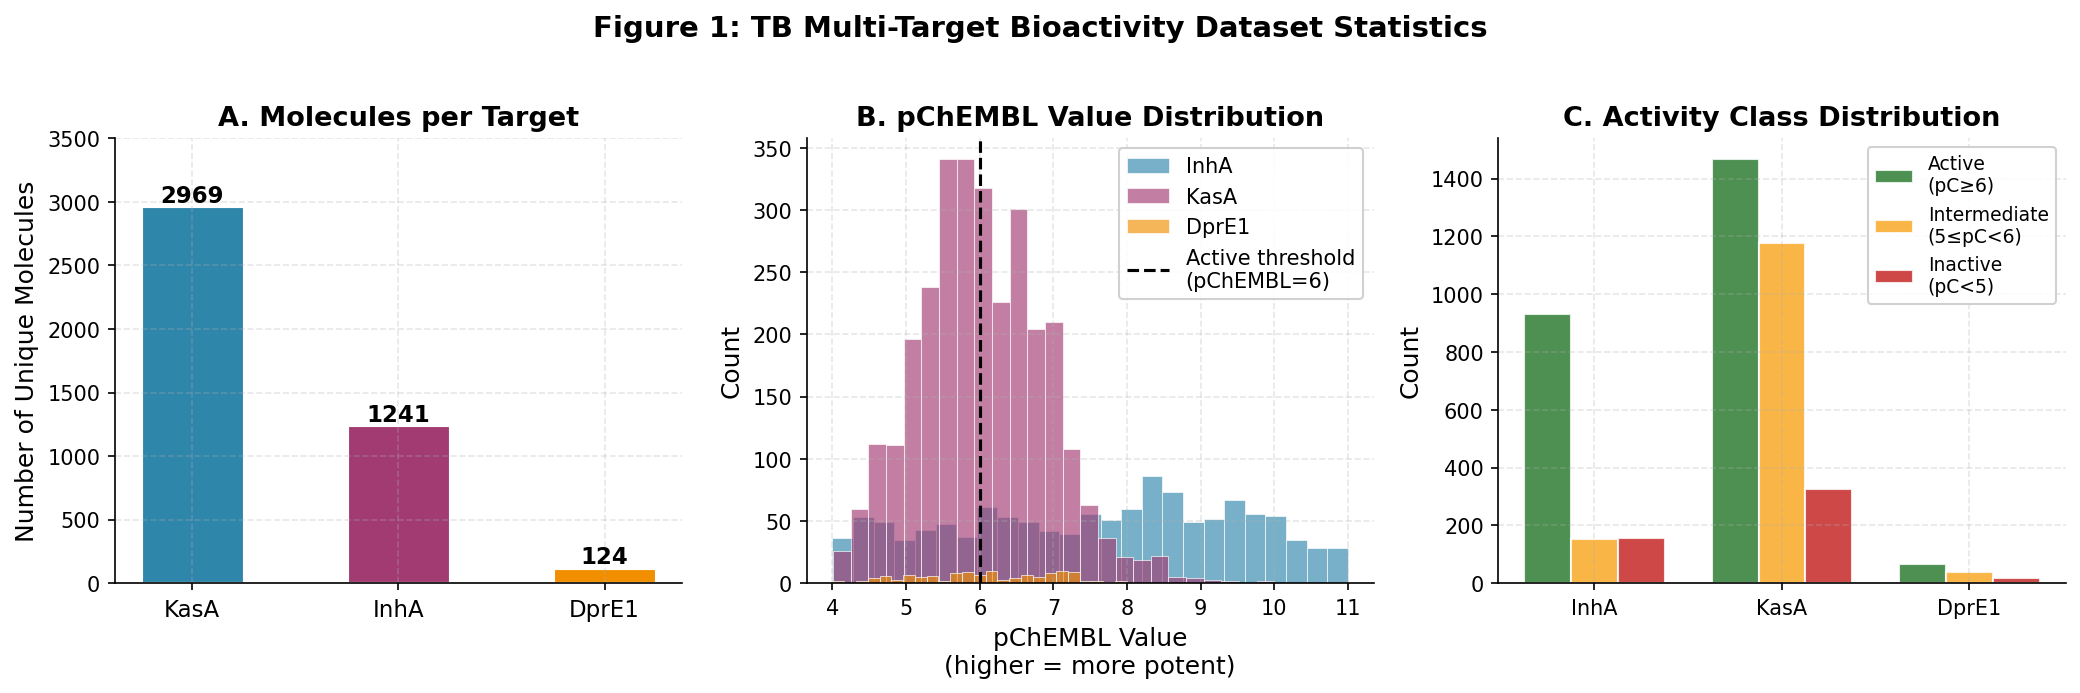

✅ Figure 1 saved: fig1_dataset_stats.png


In [27]:
# ============================================================
# MODULE 5B: Figure 1 — Dataset Statistics
# 3-panel figure showing dataset composition
# ============================================================

long_df = pd.read_csv('TB_multitarget_long.csv')

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle(
    'Figure 1: TB Multi-Target Bioactivity Dataset Statistics',
    fontsize=14, fontweight='bold', y=1.02
)

# ── Panel A: Sample counts per target ─────────────────────
ax = axes[0]
counts = long_df['target_name'].value_counts()
bars = ax.bar(
    counts.index, counts.values,
    color=TARGET_COLORS, width=0.5,
    edgecolor='white', linewidth=1.5
)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 30,
            str(val), ha='center',
            fontweight='bold', fontsize=11)
ax.set_title('A. Molecules per Target',
             fontweight='bold')
ax.set_ylabel('Number of Unique Molecules')
ax.set_ylim(0, counts.max() * 1.18)
ax.set_xticklabels(counts.index, fontsize=11)

# ── Panel B: pChEMBL distribution per target ──────────────
ax = axes[1]
for tname, color in zip(TARGET_NAMES, TARGET_COLORS):
    subset = long_df[
        long_df['target_name'] == tname
    ]['pchembl_value']
    ax.hist(subset, bins=25, alpha=0.65,
            color=color, label=tname,
            edgecolor='white', linewidth=0.5)

ax.axvline(x=6.0, color='black',
           linestyle='--', linewidth=1.5,
           label='Active threshold\n(pChEMBL=6)')
ax.set_title('B. pChEMBL Value Distribution',
             fontweight='bold')
ax.set_xlabel('pChEMBL Value\n(higher = more potent)')
ax.set_ylabel('Count')
ax.legend(framealpha=0.9)

# ── Panel C: Activity class breakdown ─────────────────────
ax = axes[2]

activity_counts = {}
for tname in TARGET_NAMES:
    subset = long_df[long_df['target_name'] == tname]
    active  = (subset['pchembl_value'] >= 6).sum()
    inter   = ((subset['pchembl_value'] >= 5) &
               (subset['pchembl_value'] < 6)).sum()
    inactive = (subset['pchembl_value'] < 5).sum()
    activity_counts[tname] = [active, inter, inactive]

x      = np.arange(len(TARGET_NAMES))
width  = 0.25
labels = ['Active\n(pC≥6)',
          'Intermediate\n(5≤pC<6)',
          'Inactive\n(pC<5)']
act_colors = ['#2E7D32', '#F9A825', '#C62828']

for i, (label, color) in enumerate(
        zip(labels, act_colors)):
    vals = [activity_counts[t][i]
            for t in TARGET_NAMES]
    bars = ax.bar(x + i*width, vals,
                  width=width, label=label,
                  color=color, alpha=0.85,
                  edgecolor='white')

ax.set_title('C. Activity Class Distribution',
             fontweight='bold')
ax.set_ylabel('Count')
ax.set_xticks(x + width)
ax.set_xticklabels(TARGET_NAMES)
ax.legend(framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig('fig1_dataset_stats.png',
            dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✅ Figure 1 saved: fig1_dataset_stats.png")

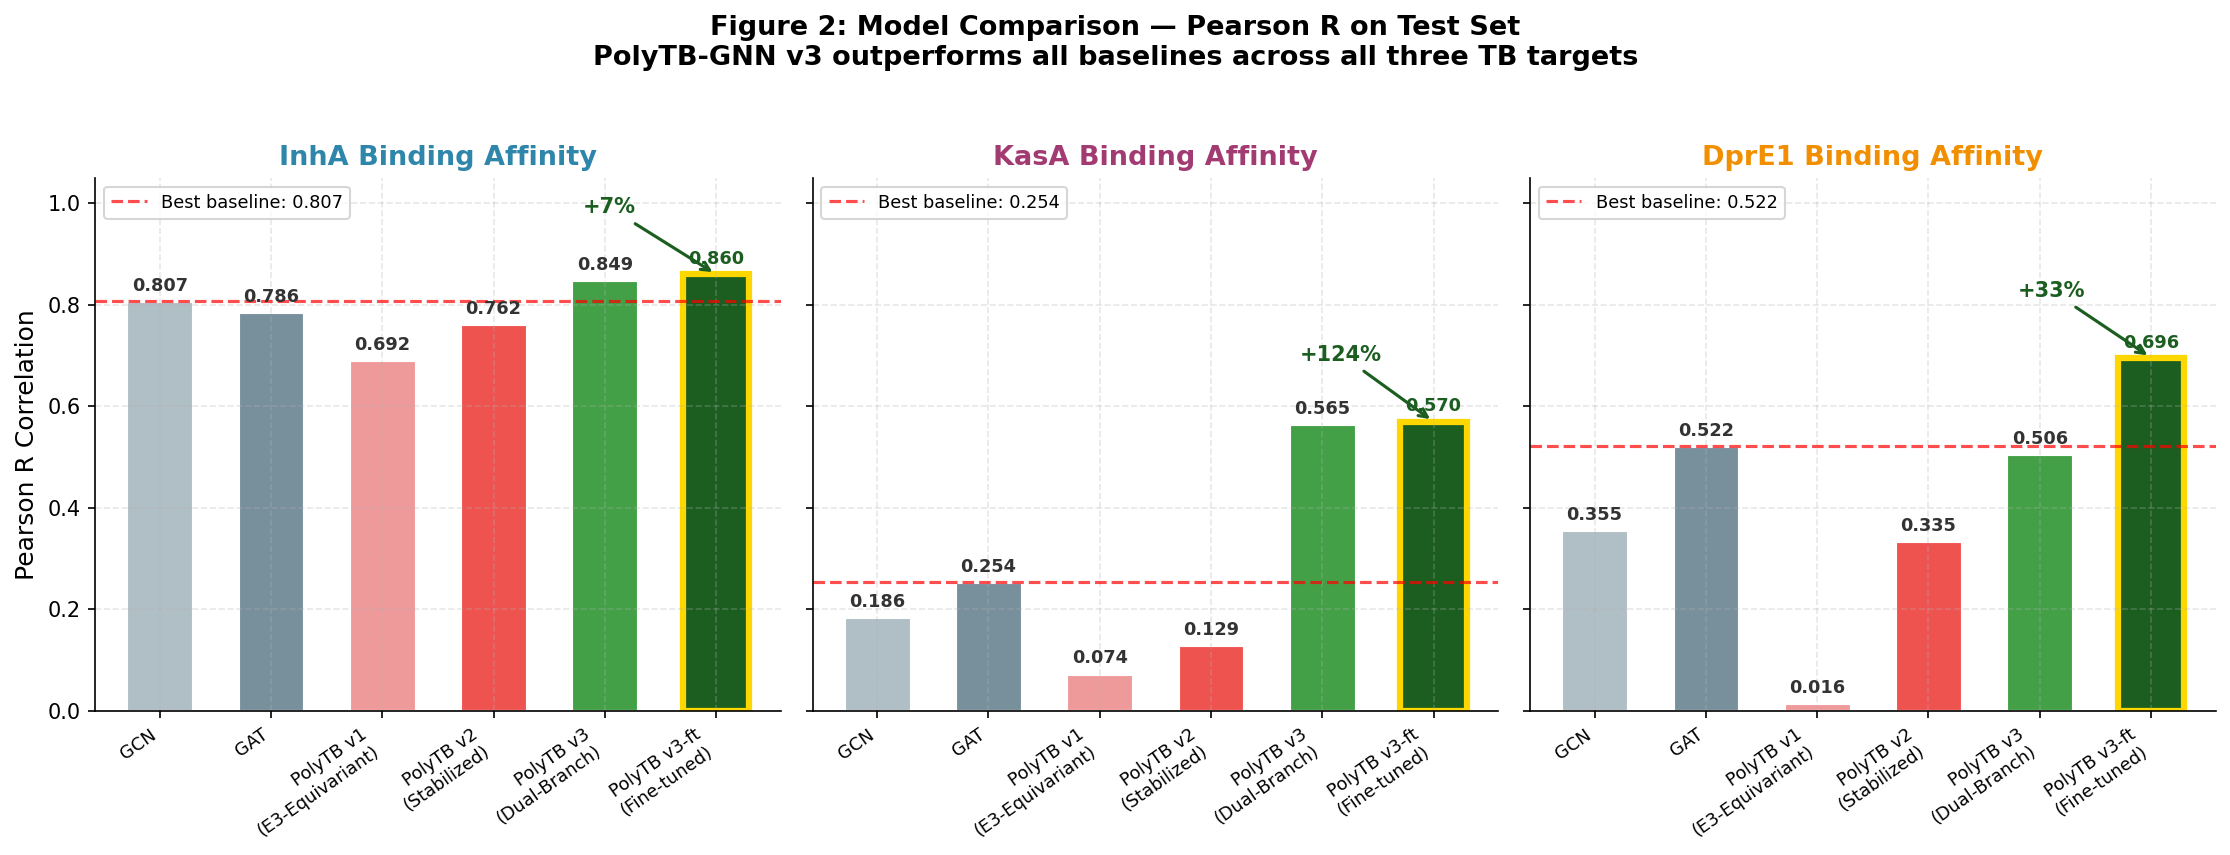

✅ Figure 2 saved: fig2_model_comparison.png


In [28]:
# ============================================================
# MODULE 5C: Figure 2 — Model Comparison (Headline Result)
# This is the most important figure in the paper
# ============================================================

model_results = {
    'GCN':             {'InhA': 0.8073, 'KasA': 0.1857, 'DprE1': 0.3554},
    'GAT':             {'InhA': 0.7863, 'KasA': 0.2540, 'DprE1': 0.5222},
    'PolyTB v1\n(E3-Equivariant)':
                       {'InhA': 0.6919, 'KasA': 0.0737, 'DprE1': 0.0162},
    'PolyTB v2\n(Stabilized)':
                       {'InhA': 0.7618, 'KasA': 0.1292, 'DprE1': 0.3354},
    'PolyTB v3\n(Dual-Branch)':
                       {'InhA': 0.8488, 'KasA': 0.5651, 'DprE1': 0.5059},
    'PolyTB v3-ft\n(Fine-tuned)':
                       {'InhA': 0.8599, 'KasA': 0.5699, 'DprE1': 0.6958},
}

model_names = list(model_results.keys())
bar_colors  = [
    COLORS['GCN'], COLORS['GAT'],
    COLORS['v1'],  COLORS['v2'],
    COLORS['v3'],  COLORS['v3ft']
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5),
                          sharey=True)
fig.suptitle(
    'Figure 2: Model Comparison — Pearson R on Test Set\n'
    'PolyTB-GNN v3 outperforms all baselines '
    'across all three TB targets',
    fontsize=13, fontweight='bold', y=1.03
)

for ax, target in zip(axes, TARGET_NAMES):
    vals = [model_results[m][target]
            for m in model_names]

    bars = ax.bar(
        range(len(model_names)), vals,
        color=bar_colors,
        edgecolor='white', linewidth=1.5,
        width=0.6
    )

    # Highlight best bar
    best_idx = int(np.argmax(vals))
    bars[best_idx].set_edgecolor('#FFD700')
    bars[best_idx].set_linewidth(3)

    # Value labels on bars
    for i, (bar, val) in enumerate(zip(bars, vals)):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            val + 0.012,
            f'{val:.3f}',
            ha='center', va='bottom',
            fontsize=8.5, fontweight='bold',
            color='#1B5E20' if i == best_idx else '#333'
        )

    # Baseline reference line (best non-PolyTB)
    baseline_best = max(
        model_results['GCN'][target],
        model_results['GAT'][target]
    )
    ax.axhline(y=baseline_best,
               color='red', linestyle='--',
               linewidth=1.5, alpha=0.7,
               label=f'Best baseline: {baseline_best:.3f}')

    ax.set_title(f'{target} Binding Affinity',
                 fontweight='bold',
                 color=COLORS[target])
    ax.set_ylabel('Pearson R Correlation' if target == 'InhA'
                  else '')
    ax.set_ylim(0, 1.05)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names,
                       rotation=35, ha='right',
                       fontsize=8.5)
    ax.legend(fontsize=8.5, loc='upper left')

    # Improvement annotation for v3-ft
    baseline = baseline_best
    best_val = model_results[
        'PolyTB v3-ft\n(Fine-tuned)'
    ][target]
    pct = (best_val - baseline) / baseline * 100
    ax.annotate(
        f'+{pct:.0f}%',
        xy=(5, best_val),
        xytext=(3.8, best_val + 0.12),
        fontsize=10, fontweight='bold',
        color=COLORS['v3ft'],
        arrowprops=dict(
            arrowstyle='->', color=COLORS['v3ft'],
            lw=1.5
        )
    )

plt.tight_layout()
plt.savefig('fig2_model_comparison.png',
            dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✅ Figure 2 saved: fig2_model_comparison.png")

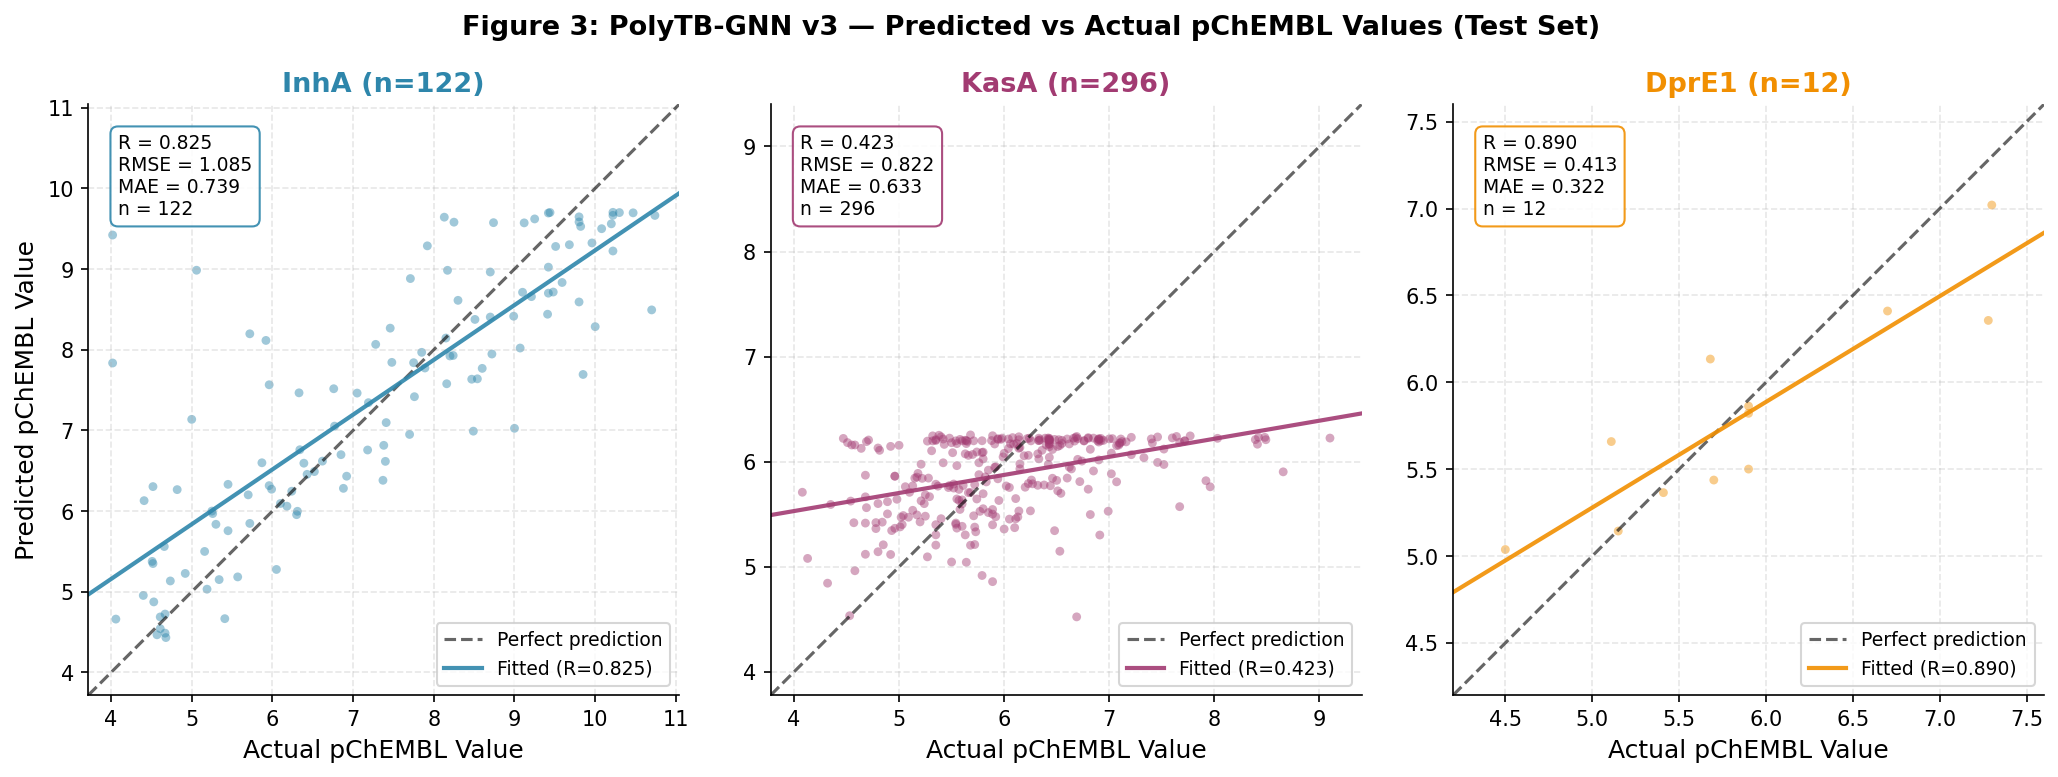

✅ Figure 3 saved: fig3_scatter_plots.png


In [29]:
# ============================================================
# MODULE 5D: Figure 3 — Predicted vs Actual Scatter Plots
# Shows model calibration per target
# ============================================================

# Get predictions from best model on test set
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

model_v3_ft = PolyTB_GNN_v3()
model_v3_ft.load_state_dict(
    torch.load('polytb_gnn_v3_finetuned.pt',
               map_location=device)
)
model_v3_ft = model_v3_ft.to(device)
model_v3_ft.eval()

all_preds   = {t: [] for t in TARGET_NAMES}
all_actuals = {t: [] for t in TARGET_NAMES}

with torch.no_grad():
    for batch in test_loader:
        batch  = batch.to(device)
        pred   = model_v3_ft(batch)
        target = batch.y.view(-1, 3)
        mask   = batch.mask.view(-1, 3)

        for i, tname in enumerate(TARGET_NAMES):
            t_mask = mask[:, i]
            if t_mask.sum() > 0:
                all_preds[tname].extend(
                    pred[t_mask, i].cpu().numpy()
                )
                all_actuals[tname].extend(
                    target[t_mask, i].cpu().numpy()
                )

# ── Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))
fig.suptitle(
    'Figure 3: PolyTB-GNN v3 — Predicted vs Actual '
    'pChEMBL Values (Test Set)',
    fontsize=13, fontweight='bold', y=1.02
)

for ax, tname, color in zip(
        axes, TARGET_NAMES, TARGET_COLORS):

    y_pred   = np.array(all_preds[tname])
    y_actual = np.array(all_actuals[tname])
    r, _     = pearsonr(y_pred, y_actual)

    # Scatter
    ax.scatter(y_actual, y_pred,
               alpha=0.45, s=18,
               color=color, edgecolors='none')

    # Perfect prediction line
    lims = [
        min(y_actual.min(), y_pred.min()) - 0.3,
        max(y_actual.max(), y_pred.max()) + 0.3
    ]
    ax.plot(lims, lims, 'k--',
            linewidth=1.5, alpha=0.6,
            label='Perfect prediction')

    # Regression line
    m, b   = np.polyfit(y_actual, y_pred, 1)
    x_line = np.linspace(lims[0], lims[1], 100)
    ax.plot(x_line, m * x_line + b,
            color=color, linewidth=2,
            alpha=0.9,
            label=f'Fitted (R={r:.3f})')

    # Stats box
    rmse = np.sqrt(np.mean((y_pred - y_actual)**2))
    mae  = np.mean(np.abs(y_pred - y_actual))
    stats_text = (f'R = {r:.3f}\n'
                  f'RMSE = {rmse:.3f}\n'
                  f'MAE = {mae:.3f}\n'
                  f'n = {len(y_pred)}')
    ax.text(0.05, 0.95, stats_text,
            transform=ax.transAxes,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='white',
                      edgecolor=color,
                      alpha=0.9))

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Actual pChEMBL Value')
    ax.set_ylabel('Predicted pChEMBL Value'
                  if tname == 'InhA' else '')
    ax.set_title(f'{tname} (n={len(y_pred)})',
                 fontweight='bold', color=color)
    ax.legend(fontsize=9)
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('fig3_scatter_plots.png',
            dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✅ Figure 3 saved: fig3_scatter_plots.png")

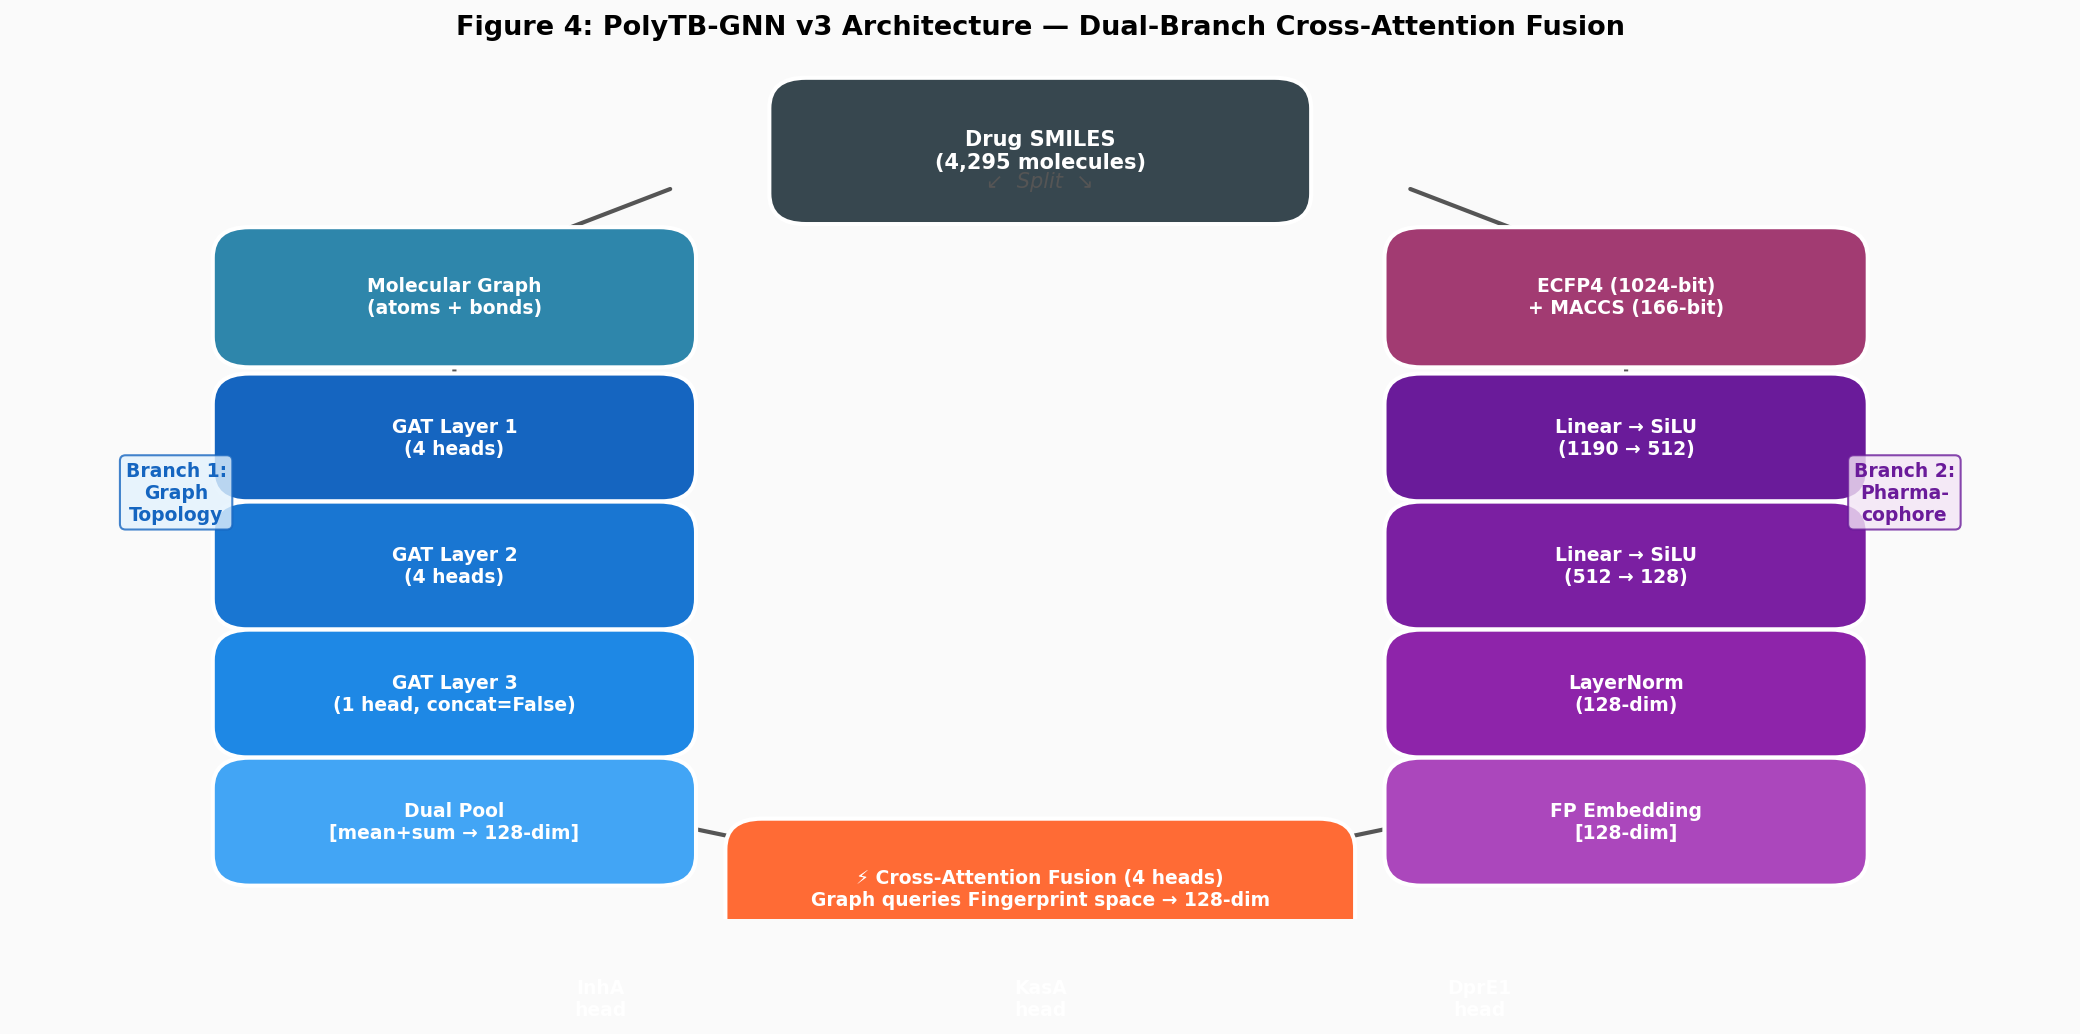

✅ Figure 4 saved: fig4_architecture.png


In [30]:
# ============================================================
# MODULE 5E: Figure 4 — Architecture Diagram (SVG-style)
# Clean visual of PolyTB-GNN v3 dual-branch architecture
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(14, 7))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis('off')
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('#FAFAFA')

def box(ax, x, y, w, h, color, text,
        fontsize=9, radius=0.25, text_color='white'):
    fancy = mpatches.FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle=f"round,pad={radius}",
        facecolor=color, edgecolor='white',
        linewidth=2, zorder=3
    )
    ax.add_patch(fancy)
    ax.text(x, y, text, ha='center', va='center',
            fontsize=fontsize, fontweight='bold',
            color=text_color, zorder=4,
            wrap=True, multialignment='center')

def arrow(ax, x1, y1, x2, y2, color='#555'):
    ax.annotate('',
        xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(
            arrowstyle='->', color=color,
            lw=2.0, connectionstyle='arc3,rad=0.0'
        ), zorder=2
    )

# ── Input ─────────────────────────────────────────────────
box(ax, 7, 6.3, 3.2, 0.7,
    '#37474F', 'Drug SMILES\n(4,295 molecules)',
    fontsize=10)

# Branch split arrows
arrow(ax, 4.5, 6.0, 3.2, 5.4)   # left branch
arrow(ax, 9.5, 6.0, 10.8, 5.4)  # right branch
ax.text(7, 6.0, '↙  Split  ↘',
        ha='center', fontsize=10,
        color='#555', style='italic')

# ── Branch 1: GAT ─────────────────────────────────────────
box(ax, 3.0, 5.1, 2.8, 0.65,
    COLORS['InhA'], 'Molecular Graph\n(atoms + bonds)',
    fontsize=9)
arrow(ax, 3.0, 4.77, 3.0, 4.22)
box(ax, 3.0, 3.95, 2.8, 0.55,
    '#1565C0', 'GAT Layer 1\n(4 heads)',
    fontsize=9)
arrow(ax, 3.0, 3.67, 3.0, 3.17)
box(ax, 3.0, 2.9, 2.8, 0.55,
    '#1976D2', 'GAT Layer 2\n(4 heads)',
    fontsize=9)
arrow(ax, 3.0, 2.62, 3.0, 2.12)
box(ax, 3.0, 1.85, 2.8, 0.55,
    '#1E88E5', 'GAT Layer 3\n(1 head, concat=False)',
    fontsize=9)
arrow(ax, 3.0, 1.57, 3.0, 1.07)
box(ax, 3.0, 0.8, 2.8, 0.55,
    '#42A5F5', 'Dual Pool\n[mean+sum → 128-dim]',
    fontsize=9)

# Branch 1 label
ax.text(1.1, 3.5, 'Branch 1:\nGraph\nTopology',
        ha='center', va='center',
        fontsize=9, color='#1565C0',
        fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='#E3F2FD',
                  edgecolor='#1565C0', alpha=0.8))

# ── Branch 2: Fingerprints ────────────────────────────────
box(ax, 11.0, 5.1, 2.8, 0.65,
    COLORS['KasA'], 'ECFP4 (1024-bit)\n+ MACCS (166-bit)',
    fontsize=9)
arrow(ax, 11.0, 4.77, 11.0, 4.22)
box(ax, 11.0, 3.95, 2.8, 0.55,
    '#6A1B9A', 'Linear → SiLU\n(1190 → 512)',
    fontsize=9)
arrow(ax, 11.0, 3.67, 11.0, 3.17)
box(ax, 11.0, 2.9, 2.8, 0.55,
    '#7B1FA2', 'Linear → SiLU\n(512 → 128)',
    fontsize=9)
arrow(ax, 11.0, 2.62, 11.0, 2.12)
box(ax, 11.0, 1.85, 2.8, 0.55,
    '#8E24AA', 'LayerNorm\n(128-dim)',
    fontsize=9)
arrow(ax, 11.0, 1.57, 11.0, 1.07)
box(ax, 11.0, 0.8, 2.8, 0.55,
    '#AB47BC', 'FP Embedding\n[128-dim]',
    fontsize=9)

# Branch 2 label
ax.text(12.9, 3.5, 'Branch 2:\nPharma-\ncophore',
        ha='center', va='center',
        fontsize=9, color='#6A1B9A',
        fontweight='bold',
        bbox=dict(boxstyle='round',
                  facecolor='#F3E5F5',
                  edgecolor='#6A1B9A', alpha=0.8))

# ── Cross Attention Fusion ────────────────────────────────
arrow(ax, 4.4, 0.8, 5.8, 0.45)
arrow(ax, 9.6, 0.8, 8.2, 0.45)
box(ax, 7.0, 0.25, 3.8, 0.65,
    COLORS['highlight'],
    '⚡ Cross-Attention Fusion (4 heads)\n'
    'Graph queries Fingerprint space → 128-dim',
    fontsize=9)

# ── Output heads ──────────────────────────────────────────
arrow(ax, 5.2, 0.25, 4.0, -0.3)
arrow(ax, 7.0, -0.08, 7.0, -0.3)
arrow(ax, 8.8, 0.25, 10.0, -0.3)

for x, label, color in zip(
    [4.0, 7.0, 10.0],
    ['InhA\nhead', 'KasA\nhead', 'DprE1\nhead'],
    TARGET_COLORS
):
    box(ax, x, -0.65, 2.2, 0.62,
        color, label, fontsize=9)

# Title
ax.set_title(
    'Figure 4: PolyTB-GNN v3 Architecture — '
    'Dual-Branch Cross-Attention Fusion',
    fontsize=13, fontweight='bold', pad=15
)

plt.tight_layout()
plt.savefig('fig4_architecture.png',
            dpi=300, bbox_inches='tight',
            facecolor='#FAFAFA')
plt.show()
print("✅ Figure 4 saved: fig4_architecture.png")

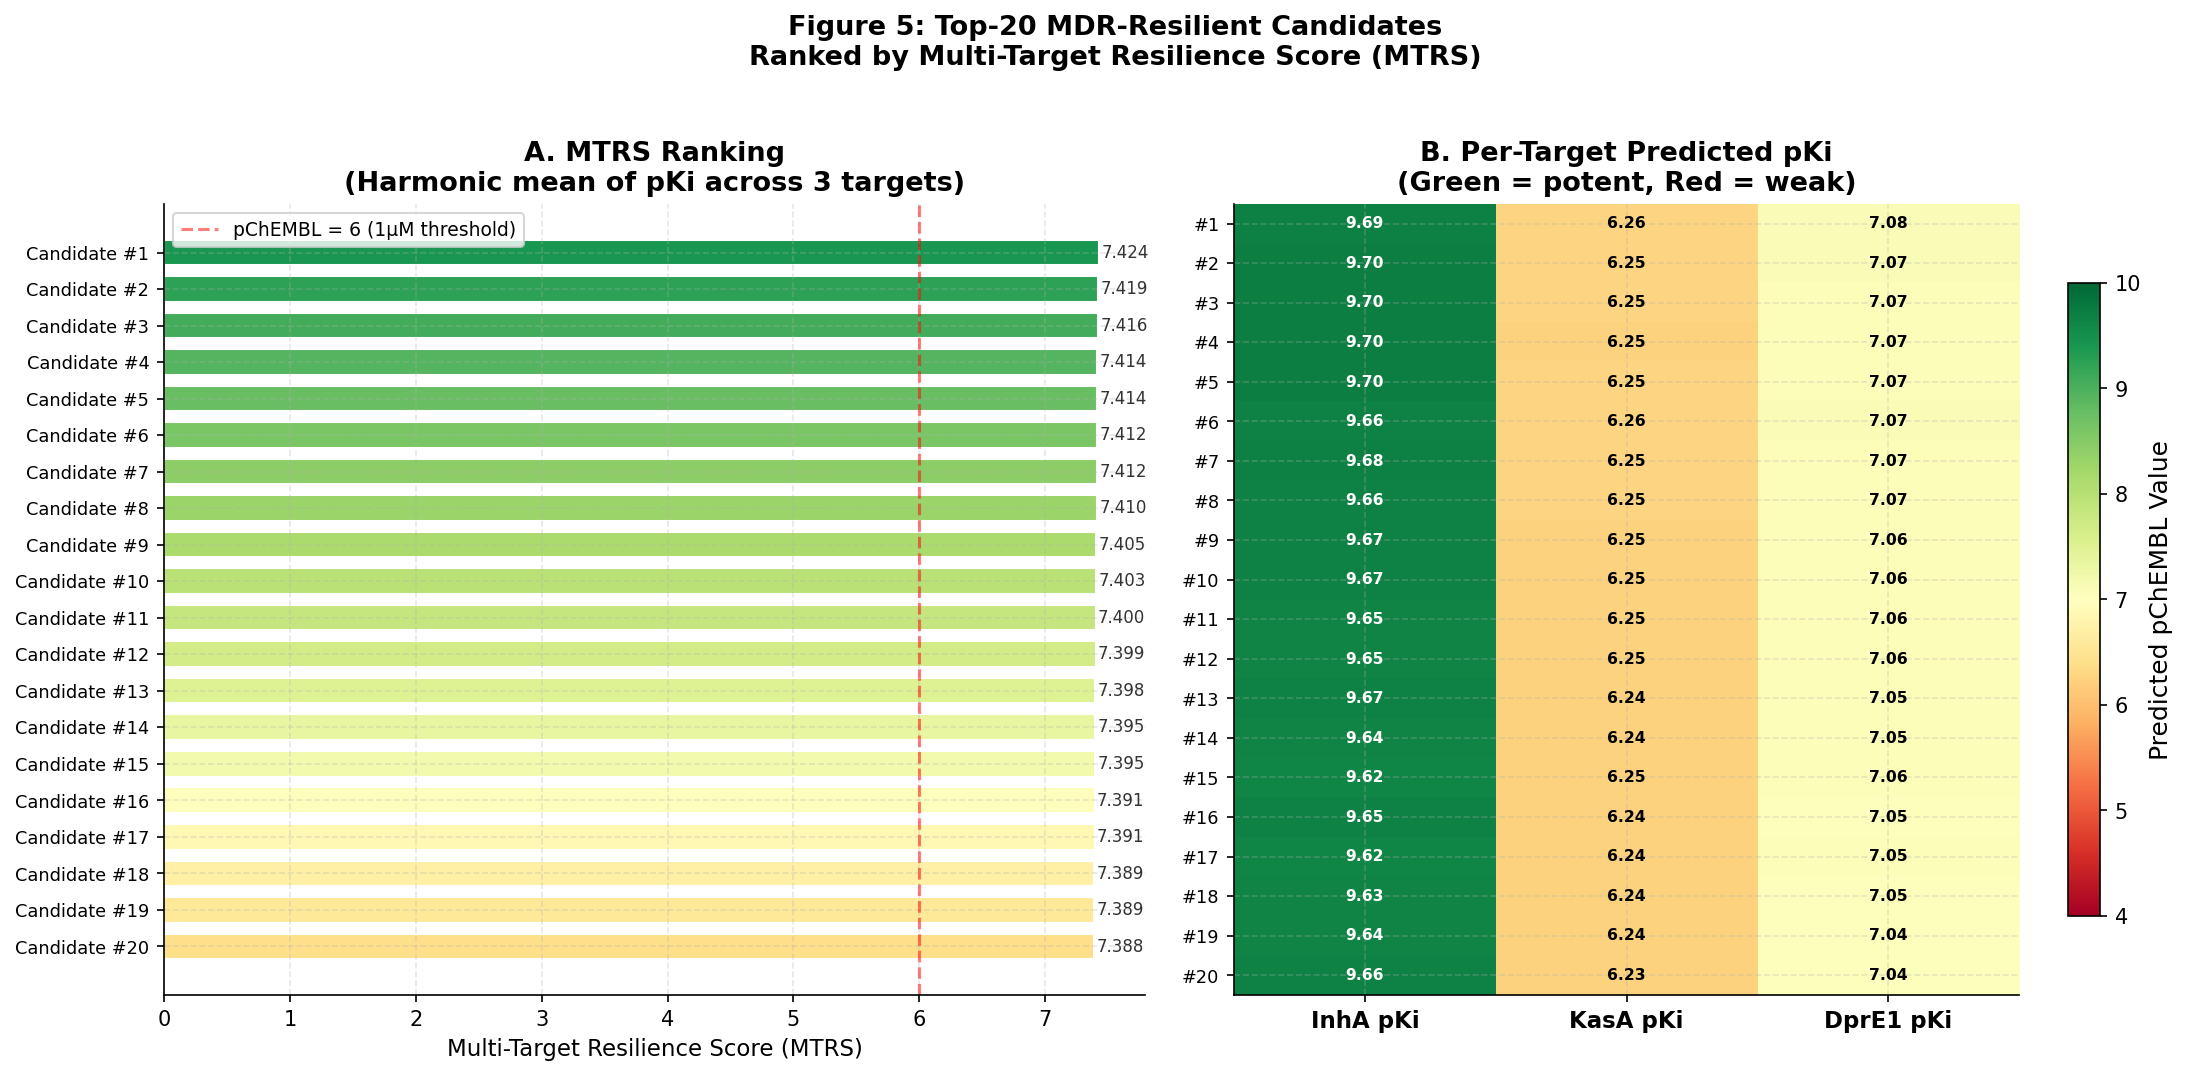

✅ Figure 5 saved: fig5_top20_candidates.png


In [31]:
# ============================================================
# MODULE 5F: Figure 5 — Top-20 MTRS Candidates
# ============================================================

# Recompute MTRS on full test set with fine-tuned model
scored_df = compute_resilience_scores(
    model_v3_ft, test_loader, device
)
top20 = scored_df.head(20).copy()
top20['rank'] = range(1, 21)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle(
    'Figure 5: Top-20 MDR-Resilient Candidates\n'
    'Ranked by Multi-Target Resilience Score (MTRS)',
    fontsize=13, fontweight='bold', y=1.02
)

# ── Panel A: MTRS bar chart ───────────────────────────────
ax = axes[0]
colors_bar = plt.cm.RdYlGn(
    np.linspace(0.4, 0.9, 20)
)[::-1]

bars = ax.barh(
    range(20, 0, -1),
    top20['MTRS'].values,
    color=colors_bar,
    edgecolor='white', height=0.7
)

ax.set_yticks(range(20, 0, -1))
ax.set_yticklabels(
    [f'Candidate #{i}' for i in range(1, 21)],
    fontsize=8.5
)
ax.set_xlabel('Multi-Target Resilience Score (MTRS)',
              fontsize=11)
ax.set_title('A. MTRS Ranking\n'
             '(Harmonic mean of pKi across 3 targets)',
             fontweight='bold')
ax.axvline(x=6.0, color='red',
           linestyle='--', alpha=0.5,
           label='pChEMBL = 6 (1µM threshold)')
ax.legend(fontsize=9)

# Add value labels
for i, (bar, val) in enumerate(
        zip(bars, top20['MTRS'].values)):
    ax.text(val + 0.02, bar.get_y() +
            bar.get_height()/2,
            f'{val:.3f}',
            va='center', fontsize=8,
            color='#333')

# ── Panel B: Per-target scores heatmap ───────────────────
ax = axes[1]

heatmap_data = top20[
    ['pred_InhA', 'pred_KasA', 'pred_DprE1']
].values

im = ax.imshow(heatmap_data,
               aspect='auto',
               cmap='RdYlGn',
               vmin=4, vmax=10)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['InhA pKi', 'KasA pKi', 'DprE1 pKi'],
                   fontsize=11, fontweight='bold')
ax.set_yticks(range(20))
ax.set_yticklabels(
    [f'#{i}' for i in range(1, 21)],
    fontsize=8.5
)
ax.set_title('B. Per-Target Predicted pKi\n'
             '(Green = potent, Red = weak)',
             fontweight='bold')

# Cell value annotations
for i in range(20):
    for j in range(3):
        val = heatmap_data[i, j]
        text_color = 'white' if val > 8 or val < 5 \
                     else 'black'
        ax.text(j, i, f'{val:.2f}',
                ha='center', va='center',
                fontsize=7.5, color=text_color,
                fontweight='bold')

plt.colorbar(im, ax=ax,
             label='Predicted pChEMBL Value',
             shrink=0.8)

plt.tight_layout()
plt.savefig('fig5_top20_candidates.png',
            dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✅ Figure 5 saved: fig5_top20_candidates.png")

In [32]:
# ============================================================
# MODULE 5G: Bonus — Ablation Summary Table (for paper)
# Print as clean text + save as CSV
# ============================================================

ablation_data = {
    'Model': [
        'GCN Baseline',
        'GAT Baseline',
        'PolyTB-GNN v1\n(E3-Equivariant)',
        'PolyTB-GNN v2\n(Stabilized E3)',
        'PolyTB-GNN v3\n(Dual-Branch)',
        'PolyTB-GNN v3-ft\n(Fine-tuned)'
    ],
    'Graph Branch': [
        'GCN', 'GAT', 'EQConv (3D)',
        'EQConv (3D)', 'GAT', 'GAT'
    ],
    'FP Branch': [
        '✗', '✗', '✗', '✗',
        'ECFP4+MACCS', 'ECFP4+MACCS'
    ],
    'Fusion': [
        'None', 'None', 'None',
        'None', 'Cross-Attn', 'Cross-Attn'
    ],
    'InhA R': [0.8073, 0.7863, 0.6919,
               0.7618, 0.8488, 0.8599],
    'KasA R': [0.1857, 0.2540, 0.0737,
               0.1292, 0.5651, 0.5699],
    'DprE1 R': [0.3554, 0.5222, 0.0162,
                0.3354, 0.5059, 0.6958],
}

ablation_df = pd.DataFrame(ablation_data)
ablation_df['Mean R'] = ablation_df[
    ['InhA R', 'KasA R', 'DprE1 R']
].mean(axis=1).round(4)

print("\n" + "="*78)
print("TABLE 2: ABLATION STUDY — All Models")
print("="*78)
print(ablation_df.to_string(index=False))
print("="*78)

ablation_df.to_csv('table2_ablation.csv', index=False)
print("\n✅ Saved: table2_ablation.csv")

# Summary stats
best = ablation_df.iloc[-1]
gcn  = ablation_df.iloc[0]
gat  = ablation_df.iloc[1]

print(f"\nKey improvements over best baseline:")
print(f"  InhA:  {gat['InhA R']:.4f} → "
      f"{best['InhA R']:.4f} "
      f"(+{(best['InhA R']-gat['InhA R'])/gat['InhA R']*100:.1f}%)")
print(f"  KasA:  {gat['KasA R']:.4f} → "
      f"{best['KasA R']:.4f} "
      f"(+{(best['KasA R']-gat['KasA R'])/gat['KasA R']*100:.1f}%)")
print(f"  DprE1: {gat['DprE1 R']:.4f} → "
      f"{best['DprE1 R']:.4f} "
      f"(+{(best['DprE1 R']-gat['DprE1 R'])/gat['DprE1 R']*100:.1f}%)")
print(f"  Mean R:{ablation_df.iloc[1]['Mean R']:.4f} → "
      f"{best['Mean R']:.4f} "
      f"(+{(best['Mean R']-ablation_df.iloc[1]['Mean R'])/ablation_df.iloc[1]['Mean R']*100:.1f}%)")


TABLE 2: ABLATION STUDY — All Models
                          Model Graph Branch   FP Branch     Fusion  InhA R  KasA R  DprE1 R  Mean R
                   GCN Baseline          GCN           ✗       None  0.8073  0.1857   0.3554  0.4495
                   GAT Baseline          GAT           ✗       None  0.7863  0.2540   0.5222  0.5208
PolyTB-GNN v1\n(E3-Equivariant)  EQConv (3D)           ✗       None  0.6919  0.0737   0.0162  0.2606
 PolyTB-GNN v2\n(Stabilized E3)  EQConv (3D)           ✗       None  0.7618  0.1292   0.3354  0.4088
   PolyTB-GNN v3\n(Dual-Branch)          GAT ECFP4+MACCS Cross-Attn  0.8488  0.5651   0.5059  0.6399
 PolyTB-GNN v3-ft\n(Fine-tuned)          GAT ECFP4+MACCS Cross-Attn  0.8599  0.5699   0.6958  0.7085

✅ Saved: table2_ablation.csv

Key improvements over best baseline:
  InhA:  0.7863 → 0.8599 (+9.4%)
  KasA:  0.2540 → 0.5699 (+124.4%)
  DprE1: 0.5222 → 0.6958 (+33.2%)
  Mean R:0.5208 → 0.7085 (+36.0%)
